In [4]:
# alignment_module.py
# UHI ↔ MBES: utilities + alignment search with progress bar & subsampling

from __future__ import annotations
import os, json, csv, time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation
from pyproj import Transformer
import rasterio
import sys

sys.path.append(os.path.abspath("../"))
# repo modules (present in your environment)
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# Small helpers
# -----------------------------
def robust_z(a: np.ndarray) -> np.ndarray:
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    vmax = np.quantile(np.abs(finite), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """EXACT jagged outline (includes outer edges)."""
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left/right
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top/bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# -----------------------------
# MBES detrending
# -----------------------------
@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        if self.data is None:
            self.load()
        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)
        self.trend = trend
        self.residuals = z - trend
        return self

    def robust_sym_vlim(self, arr=None, q=0.98):
        a = self.residuals if arr is None else arr
        return robust_sym_vlim(a, q=q)


# -----------------------------
# Search spec & gates
# -----------------------------
@dataclass
class LevelSpec:
    theta_range: Tuple[float, float]
    theta_step: float
    dx_range: Tuple[float, float]
    dy_range: Tuple[float, float]
    step_xy: float
    stride: int = 1  # sample every Nth MBES pixel
    k: int = 1
    sigma: float = 0.0  # reserved
    sample_frac: float = 1.0  # 0< x ≤1 : random subsample of grid
    max_tries: Optional[int] = None  # hard cap on tries (for quick tests)


@dataclass
class GateSpec:
    min_pairs: int = 1000
    min_score: float = -0.25
    stop_if_score_ge: float = 0.35


# -----------------------------
# Alignment search
# -----------------------------
class AlignmentSearch:
    def __init__(self, E, N, mask_valid, uhi_corr, mb: MBESDetrender, lat0, lon0, h0):
        self.E = E
        self.N = N
        self.mask_valid = mask_valid.astype(bool)
        self.uhi_corr = uhi_corr

        # jagged footprint
        Xc, Yc = pcolormesh_pad(E, N)
        segs_xy, segs_idx = boundary_segments_from_mask(self.mask_valid, Xc, Yc)
        loops = trace_loops_from_segments(segs_idx)
        self.footprint_path0 = compound_path_from_loops(loops, Xc, Yc)
        self.outline_lc = LineCollection(segs_xy, colors="k", linewidths=1.1, alpha=0.9)

        # UHI KDTree
        valid_uhi = (
            self.mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
        )
        self.uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        self.uhi_vals = uhi_corr[valid_uhi]
        if self.uhi_pts.size == 0:
            raise RuntimeError("No valid UHI points for KDTree.")
        self.tree_uhi = cKDTree(self.uhi_pts)

        # pivot = footprint centroid
        self.cx = float(np.nanmean(E[valid_uhi]))
        self.cy = float(np.nanmean(N[valid_uhi]))

        # MBES → NED (once)
        MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
        epsg_src = getattr(mb, "epsg", 32633) if getattr(mb, "epsg", None) else 32633
        tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
        mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
        tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
            mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
        )
        mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
            mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
        )
        self.mbes_e = mbes_e_ned
        self.mbes_n = mbes_n_ned
        self.mbes_res = mb.residuals
        self.P_mbes = np.column_stack([self.mbes_e.ravel(), self.mbes_n.ravel()])

        # base sanity
        base_inside = self.footprint_path0.contains_points(self.P_mbes)
        self.base_pairs = int(np.sum(base_inside))
        if self.base_pairs == 0:
            raise RuntimeError(
                "No MBES pixels inside UHI footprint at base (θ=0, dx=0, dy=0). "
                "Check transform or slices."
            )

    @staticmethod
    def pearson_r(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10:
            return np.nan
        x = x[m]
        y = y[m]
        x = (x - x.mean()) / (x.std(ddof=1) or 1.0)
        y = (y - y.mean()) / (y.std(ddof=1) or 1.0)
        return float(np.clip(np.corrcoef(x, y)[0, 1], -1, 1))

    def score_one(self, theta_deg, dx, dy, stride, k, min_pairs) -> Tuple[float, int]:
        rad = np.deg2rad(theta_deg)
        c, s = np.cos(rad), np.sin(rad)
        Rinv = np.array([[c, s], [-s, c]], float)

        P = self.P_mbes[::stride]
        Pprime = (P - np.array([dx, dy])) - np.array([self.cx, self.cy])
        Pprime = Pprime @ Rinv.T + np.array([self.cx, self.cy])

        inside = self.footprint_path0.contains_points(Pprime)
        if not inside.any():
            return np.nan, 0
        idx_inside = np.where(inside)[0]
        if idx_inside.size < min_pairs:
            return np.nan, int(idx_inside.size)

        d, nn = self.tree_uhi.query(Pprime[idx_inside], k=k)
        u = self.uhi_vals[nn].astype(float).ravel()
        z = self.mbes_res.ravel()[::stride][idx_inside].astype(float).ravel()
        return self.pearson_r(u, z), int(idx_inside.size)

    def run(
        self,
        levels: List[LevelSpec],
        gates: GateSpec,
        log_csv: Optional[str] = None,
        viz_every: int = 0,
        show_progress: bool = True,
        show_final: bool = True,
        rng_seed: int = 0,
    ) -> Dict:
        writer = None
        f_csv = None
        if log_csv:
            exists = os.path.exists(log_csv)
            f_csv = open(log_csv, "a", newline="")
            writer = csv.writer(f_csv)
            if not exists:
                writer.writerow(
                    [
                        "ts",
                        "level",
                        "theta_deg",
                        "dx_m",
                        "dy_m",
                        "stride",
                        "k",
                        "pairs",
                        "score",
                    ]
                )

        best = {
            "score": -np.inf,
            "theta": 0.0,
            "dx": 0.0,
            "dy": 0.0,
            "n": 0,
            "level": -1,
        }
        rng = np.random.default_rng(rng_seed)

        # progress bar util
        try:
            from tqdm import tqdm

            have_tqdm = True
        except Exception:
            have_tqdm = False

        try:
            for li, lvl in enumerate(levels, 1):
                th_vals = np.arange(
                    lvl.theta_range[0], lvl.theta_range[1] + 1e-9, lvl.theta_step
                )
                dx_vals = np.arange(
                    lvl.dx_range[0], lvl.dx_range[1] + 1e-9, lvl.step_xy
                )
                dy_vals = np.arange(
                    lvl.dy_range[0], lvl.dy_range[1] + 1e-9, lvl.step_xy
                )

                # full grid → optional subsample/limit
                grid = np.array(np.meshgrid(th_vals, dy_vals, dx_vals, indexing="ij"))
                combos = grid.reshape(3, -1).T  # (n,3): [th, dy, dx]
                n_total = combos.shape[0]

                sel_idx = np.arange(n_total)
                if 0 < lvl.sample_frac < 1.0:
                    n_pick = max(1, int(np.floor(n_total * lvl.sample_frac)))
                    sel_idx = rng.choice(sel_idx, size=n_pick, replace=False)
                if lvl.max_tries is not None:
                    n_pick2 = min(len(sel_idx), int(lvl.max_tries))
                    sel_idx = sel_idx[:n_pick2]
                combos = combos[sel_idx]
                n_eval = combos.shape[0]

                pbar = (
                    tqdm(total=n_eval, desc=f"Level {li}", unit="try")
                    if (have_tqdm and show_progress)
                    else None
                )

                level_best = -np.inf
                accepted = 0
                for j, (th, dy, dx) in enumerate(combos, 1):
                    score, pairs = self.score_one(
                        float(th),
                        float(dx),
                        float(dy),
                        lvl.stride,
                        lvl.k,
                        gates.min_pairs,
                    )
                    if writer:
                        writer.writerow(
                            [
                                time.time(),
                                li,
                                float(th),
                                float(dx),
                                float(dy),
                                lvl.stride,
                                lvl.k,
                                pairs,
                                score,
                            ]
                        )

                    if np.isfinite(score):
                        accepted += 1
                        if score > level_best:
                            level_best = score
                        if score > best["score"]:
                            best.update(
                                {
                                    "score": float(score),
                                    "theta": float(th),
                                    "dx": float(dx),
                                    "dy": float(dy),
                                    "n": int(pairs),
                                    "level": li,
                                }
                            )
                            if viz_every and (accepted % max(1, int(viz_every)) == 0):
                                self._quick_viz(best, title=f"Level {li} — best so far")

                    if pbar:
                        acc_rate = 100.0 * accepted / j
                        pbar.set_postfix(
                            best=f"{best['score']:.3f}",
                            level=f"{level_best:.3f}",
                            acc=f"{acc_rate:.1f}%",
                            pairs=pairs,
                        )
                        pbar.update(1)

                if pbar:
                    pbar.close()

                if accepted == 0:
                    print(
                        f"• Early stop after Level {li}: no positions reached min_pairs={gates.min_pairs}."
                    )
                    break
                if level_best < gates.min_score:
                    print(
                        f"• Early stop after Level {li}: level-best r<{gates.min_score:.2f}."
                    )
                    break
                if best["score"] >= gates.stop_if_score_ge:
                    print(
                        f"• Early stop: r≥{gates.stop_if_score_ge:.2f} at Level {li}."
                    )
                    break

            if show_final:
                self._quick_viz(best, title="Best alignment")

        finally:
            if f_csv:
                f_csv.close()

        return best

    def _quick_viz(self, best: Dict, title: str = ""):
        rad = np.deg2rad(best["theta"])
        c, s = np.cos(rad), np.sin(rad)
        R = np.array([[c, -s], [s, c]], float)
        dx0, dy0 = best["dx"], best["dy"]

        verts = self.footprint_path0.vertices.copy()
        mask = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
        V = verts[mask]
        V2 = (
            (V - np.array([self.cx, self.cy])) @ R.T
            + np.array([self.cx, self.cy])
            + np.array([dx0, dy0])
        )
        verts[mask] = V2
        footprint_path_best = MplPath(verts, self.footprint_path0.codes)

        vmin_mbes, vmax_mbes = robust_sym_vlim(self.mbes_res, q=0.98)
        fig, ax = plt.subplots(1, 1, figsize=(5.6, 10))
        extent_ned = [
            float(np.nanmin(self.mbes_e)),
            float(np.nanmax(self.mbes_e)),
            float(np.nanmin(self.mbes_n)),
            float(np.nanmax(self.mbes_n)),
        ]
        im = ax.imshow(
            np.ma.masked_invalid(self.mbes_res),
            extent=extent_ned,
            origin="upper",
            cmap="RdBu_r",
            vmin=vmin_mbes,
            vmax=vmax_mbes,
        )
        ax.add_patch(
            PathPatch(
                footprint_path_best,
                transform=ax.transData,
                facecolor="none",
                edgecolor="y",
                lw=1.3,
                alpha=0.95,
            )
        )
        ax.set_title(
            f"{title}\nθ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, r={best['score']:.3f}"
        )
        ax.set_xlabel("East (m)")
        ax.set_ylabel("North (m)")
        pad_limits(
            ax,
            footprint_path_best.vertices[:, 0].min(),
            footprint_path_best.vertices[:, 0].max(),
            footprint_path_best.vertices[:, 1].min(),
            footprint_path_best.vertices[:, 1].max(),
            pad_frac=0.03,
            equal_aspect=True,
        )
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label="MBES Residuals (m)")
        plt.show()


# -----------------------------
# Sensible defaults + wrapper
# -----------------------------
def default_levels_tiny() -> List[LevelSpec]:
    """Very small grid (great for smoke tests). ~27 tries."""
    return [
        LevelSpec(
            theta_range=(-1.0, 1.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=4,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_levels_small() -> List[LevelSpec]:
    """Your earlier ask: ±3° in 1° steps, ±0.5 m in 0.5 m steps. ~63 tries."""
    return [
        LevelSpec(
            theta_range=(-3.0, 3.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=2,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_levels_medium() -> List[LevelSpec]:
    """Two-pass coarse→fine, still fast if you set stride>1."""
    return [
        LevelSpec(
            theta_range=(-5.0, 5.0),
            theta_step=2.0,
            dx_range=(-1.0, 1.0),
            dy_range=(-1.0, 1.0),
            step_xy=1.0,
            stride=3,
            k=1,
            sample_frac=0.5,
            max_tries=150,
        ),
        LevelSpec(
            theta_range=(-2.0, 2.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.25,
            stride=2,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        ),
    ]


def default_gates_small() -> GateSpec:
    return GateSpec(min_pairs=1000, min_score=-0.25, stop_if_score_ge=0.35)


def auto_align_from_config(
    file_ids: List[str],
    track_start: int,
    track_end: int,
    log_csv: Optional[str],
    levels: List[LevelSpec],
    gates: GateSpec,
    metric: str = "pearson",
    viz_every: int = 10,
    show_progress: bool = True,
    show_final: bool = True,
    rng_seed: int = 0,
) -> Tuple[Dict, AlignmentSearch]:
    """One-call pipeline: load → slice → correct → detrend → search."""
    if metric.lower() != "pearson":
        print("Only 'pearson' is implemented (scale-invariant).")

    # UHI
    transect = georef.load_transect(config.OUTPUT_FOLDER)
    cube = transect.select_files(file_ids)

    X = cube.X_ecef[track_start:track_end, :]
    Y = cube.Y_ecef[track_start:track_end, :]
    Z = cube.Z_ecef[track_start:track_end, :]
    R = cube.R[track_start:track_end, :]
    G = cube.G[track_start:track_end, :]
    B = cube.B[track_start:track_end, :]

    full_valid = build_full_valid(X, Y, Z, R, G, B)

    lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
    N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)

    # illumination correction (persistent load-if-present)
    cube.apply_illumination_correction(window_size=1000, strength=1.0)
    wavelengths = cube.wavelengths
    idx_green = int(np.argmin(np.abs(wavelengths - 560.0)))
    uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

    # MBES
    mb = (
        MBESDetrender(
            config.MBES_GEOTIFF,
            smooth_baseline_m=0.5,
            smooth_tilt_m=0.5,
            smooth_center_m=1.0,
        )
        .load()
        .detrend(order_x=2, robust=True, central_frac=0.8)
    )

    # Search object (checks overlap immediately)
    aligner = AlignmentSearch(
        E=E,
        N=N,
        mask_valid=full_valid,
        uhi_corr=uhi_corr,
        mb=mb,
        lat0=lat0,
        lon0=lon0,
        h0=h0,
    )

    print(f"Start — base pairs inside footprint: {aligner.base_pairs:,}")
    aligner._quick_viz(
        {
            "theta": 0.0,
            "dx": 0.0,
            "dy": 0.0,
            "score": float("nan"),
            "n": aligner.base_pairs,
        },
        title="Start — base overlay",
    )

    best = aligner.run(
        levels=levels,
        gates=gates,
        log_csv=log_csv,
        viz_every=viz_every,
        show_progress=show_progress,
        show_final=show_final,
        rng_seed=rng_seed,
    )

    print(
        "\nFinal verdict:"
        f" r={best['score']:.3f}  θ={best['theta']:+.2f}°,"
        f" dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, pairs={best['n']}\n"
    )

    return best, aligner

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
Start — base pairs inside footprint: 56,319


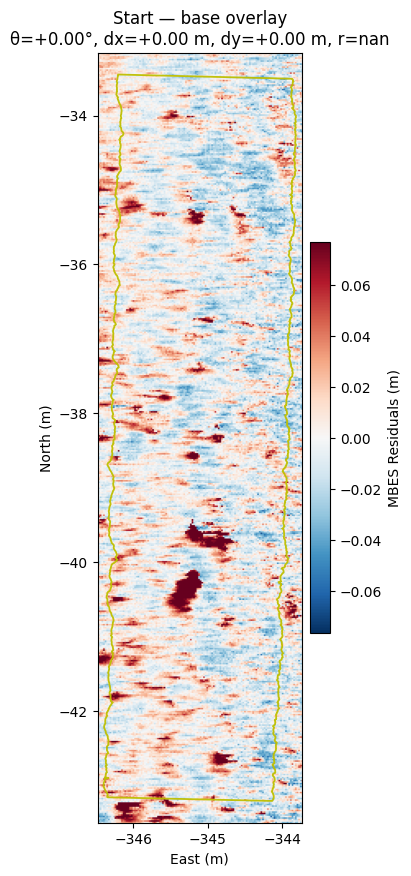

Level 1:  33%|███▎      | 9/27 [02:00<04:05, 13.65s/try, acc=100.0%, best=0.002, level=0.002, pairs=14052]

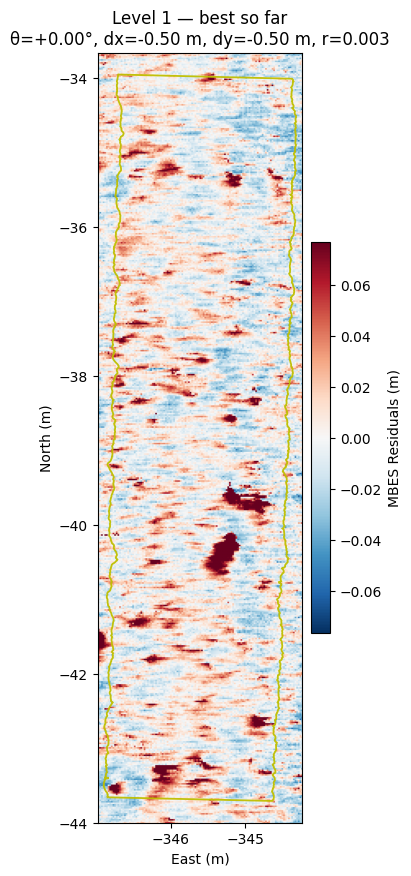

Level 1: 100%|██████████| 27/27 [05:49<00:00, 12.94s/try, acc=100.0%, best=0.007, level=0.007, pairs=14080]


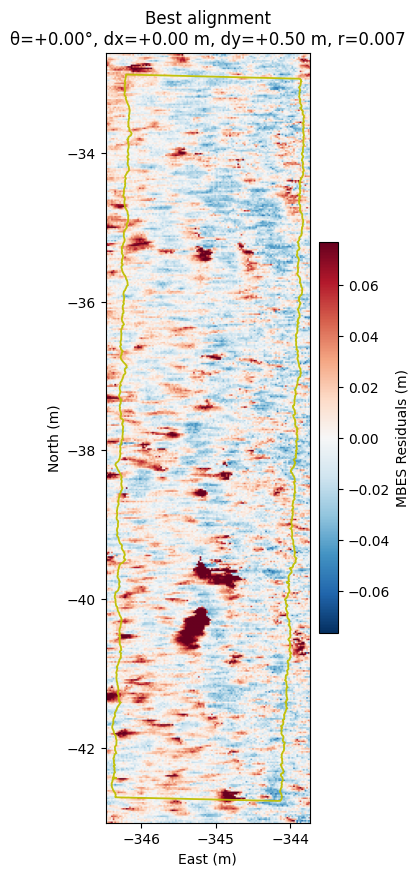


Final verdict: r=0.007  θ=+0.00°, dx=+0.00 m, dy=+0.50 m, pairs=14096

BEST: {'score': 0.006704294531838301, 'theta': 0.0, 'dx': 0.0, 'dy': 0.5, 'n': 14096, 'level': 1}


In [5]:
# run_alignment.py (paste right after File 1 in the same cell)

# QUICK TEST: tiniest grid + heavy downsampling (fast “does it run?” pass)
best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv="./alignment_search_log.csv",
    levels=default_levels_tiny(),  # try: default_levels_small() or default_levels_medium()
    gates=default_gates_small(),
    metric="pearson",
    viz_every=5,  # show overlay every 5 accepted improvements
    show_progress=True,  # tqdm bar with live best/acceptance
    show_final=True,
    rng_seed=0,  # make subsampling reproducible
)

print("BEST:", best)

try again with better visuals

In [6]:
# alignment_module.py
# UHI ↔ MBES alignment with live progress & per-level summaries.

from __future__ import annotations
import os, csv, time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation
from pyproj import Transformer
import rasterio

# repo modules (your project provides these)
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# ---------- small helpers ----------
def robust_z(a: np.ndarray) -> np.ndarray:
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    vmax = np.quantile(np.abs(finite), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """EXACT jagged outline including outer edges."""
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left/right
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top/bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# ---------- MBES detrending ----------
@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        if self.data is None:
            self.load()
        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)
        self.trend = trend
        self.residuals = z - trend
        return self

    def robust_sym_vlim(self, arr=None, q=0.98):
        a = self.residuals if arr is None else arr
        return robust_sym_vlim(a, q=q)


# ---------- search specs ----------
@dataclass
class LevelSpec:
    theta_range: Tuple[float, float]
    theta_step: float
    dx_range: Tuple[float, float]
    dy_range: Tuple[float, float]
    step_xy: float
    stride: int = 1
    k: int = 1
    sigma: float = 0.0
    sample_frac: float = 1.0  # random subsample of grid (0< x ≤1)
    max_tries: Optional[int] = None  # hard cap on grid tries


@dataclass
class GateSpec:
    min_pairs: int = 1000
    min_score: float = -0.25
    stop_if_score_ge: float = 0.35


# ---------- alignment search ----------
class AlignmentSearch:
    def __init__(self, E, N, mask_valid, uhi_corr, mb: MBESDetrender, lat0, lon0, h0):
        self.E = E
        self.N = N
        self.mask_valid = mask_valid.astype(bool)
        self.uhi_corr = uhi_corr

        # footprint path
        Xc, Yc = pcolormesh_pad(E, N)
        segs_xy, segs_idx = boundary_segments_from_mask(self.mask_valid, Xc, Yc)
        loops = trace_loops_from_segments(segs_idx)
        self.footprint_path0 = compound_path_from_loops(loops, Xc, Yc)
        self.outline_lc = LineCollection(segs_xy, colors="k", linewidths=1.1, alpha=0.9)

        # UHI KDTree
        valid_uhi = (
            self.mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
        )
        self.uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        self.uhi_vals = uhi_corr[valid_uhi]
        if self.uhi_pts.size == 0:
            raise RuntimeError("No valid UHI points for KDTree.")
        self.tree_uhi = cKDTree(self.uhi_pts)

        # pivot
        self.cx = float(np.nanmean(E[valid_uhi]))
        self.cy = float(np.nanmean(N[valid_uhi]))

        # MBES → NED (once)
        MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
        epsg_src = getattr(mb, "epsg", 32633) if getattr(mb, "epsg", None) else 32633
        tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
        mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
        tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
            mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
        )
        mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
            mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
        )
        self.mbes_e = mbes_e_ned
        self.mbes_n = mbes_n_ned
        self.mbes_res = mb.residuals
        self.P_mbes = np.column_stack([self.mbes_e.ravel(), self.mbes_n.ravel()])

        # base overlap
        base_inside = self.footprint_path0.contains_points(self.P_mbes)
        self.base_pairs = int(np.sum(base_inside))
        if self.base_pairs == 0:
            raise RuntimeError("No MBES pixels inside UHI footprint at base.")

        # keep last-level results for summaries
        self.last_level = None

    @staticmethod
    def _pearson_r(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10:
            return np.nan
        x = x[m]
        y = y[m]
        x = (x - x.mean()) / (x.std(ddof=1) or 1.0)
        y = (y - y.mean()) / (y.std(ddof=1) or 1.0)
        return float(np.clip(np.corrcoef(x, y)[0, 1], -1, 1))

    def score_one(self, theta_deg, dx, dy, stride, k, min_pairs) -> Tuple[float, int]:
        rad = np.deg2rad(theta_deg)
        c, s = np.cos(rad), np.sin(rad)
        Rinv = np.array([[c, s], [-s, c]], float)

        P = self.P_mbes[::stride]
        Pprime = (P - np.array([dx, dy])) - np.array([self.cx, self.cy])
        Pprime = Pprime @ Rinv.T + np.array([self.cx, self.cy])

        inside = self.footprint_path0.contains_points(Pprime)
        if not inside.any():
            return np.nan, 0
        idx_inside = np.where(inside)[0]
        if idx_inside.size < min_pairs:
            return np.nan, int(idx_inside.size)

        d, nn = self.tree_uhi.query(Pprime[idx_inside], k=k)
        u = self.uhi_vals[nn].astype(float).ravel()
        z = self.mbes_res.ravel()[::stride][idx_inside].astype(float).ravel()
        return self._pearson_r(u, z), int(idx_inside.size)

    def run(
        self,
        levels: List[LevelSpec],
        gates: GateSpec,
        log_csv: Optional[str] = None,
        viz_every: int = 0,
        show_progress: bool = True,
        show_final: bool = True,
        plot_each_level: bool = True,
        rng_seed: int = 0,
    ) -> Dict:
        writer = None
        f_csv = None
        if log_csv:
            exists = os.path.exists(log_csv)
            f_csv = open(log_csv, "a", newline="")
            writer = csv.writer(f_csv)
            if not exists:
                writer.writerow(
                    [
                        "ts",
                        "level",
                        "theta_deg",
                        "dx_m",
                        "dy_m",
                        "stride",
                        "k",
                        "pairs",
                        "score",
                    ]
                )

        best = {
            "score": -np.inf,
            "theta": 0.0,
            "dx": 0.0,
            "dy": 0.0,
            "n": 0,
            "level": -1,
        }

        try:
            from tqdm import tqdm

            have_tqdm = True
        except Exception:
            have_tqdm = False

        rng = np.random.default_rng(rng_seed)

        try:
            for li, lvl in enumerate(levels, 1):
                th_vals = np.arange(
                    lvl.theta_range[0], lvl.theta_range[1] + 1e-9, lvl.theta_step
                )
                dx_vals = np.arange(
                    lvl.dx_range[0], lvl.dx_range[1] + 1e-9, lvl.step_xy
                )
                dy_vals = np.arange(
                    lvl.dy_range[0], lvl.dy_range[1] + 1e-9, lvl.step_xy
                )
                nth, ndx, ndy = len(th_vals), len(dx_vals), len(dy_vals)

                # storage for level summary plots
                r_cube = np.full((nth, ndy, ndx), np.nan, dtype=float)

                # build grid and optionally subsample/limit
                grid = np.array(np.meshgrid(th_vals, dy_vals, dx_vals, indexing="ij"))
                combos = grid.reshape(3, -1).T  # (n,3): [th, dy, dx]
                n_total = combos.shape[0]
                sel_idx = np.arange(n_total)

                if 0 < lvl.sample_frac < 1.0:
                    n_pick = max(1, int(np.floor(n_total * lvl.sample_frac)))
                    sel_idx = rng.choice(sel_idx, size=n_pick, replace=False)
                if lvl.max_tries is not None:
                    sel_idx = sel_idx[: int(lvl.max_tries)]
                combos = combos[sel_idx]
                n_eval = combos.shape[0]

                pbar = (
                    tqdm(total=n_eval, desc=f"Level {li}", unit="try")
                    if (have_tqdm and show_progress)
                    else None
                )

                level_best = -np.inf
                accepted = 0

                # fast indexers from values → integer indices
                def idx_th(val):
                    return int(np.round((val - th_vals[0]) / lvl.theta_step))

                def idx_dx(val):
                    return int(np.round((val - dx_vals[0]) / lvl.step_xy))

                def idx_dy(val):
                    return int(np.round((val - dy_vals[0]) / lvl.step_xy))

                for j, (th, dy, dx) in enumerate(combos, 1):
                    score, pairs = self.score_one(
                        float(th),
                        float(dx),
                        float(dy),
                        lvl.stride,
                        lvl.k,
                        gates.min_pairs,
                    )

                    # fill cube if this point maps onto the regular grid
                    try:
                        r_cube[idx_th(th), idx_dy(dy), idx_dx(dx)] = score
                    except Exception:
                        pass  # in case of float roundoff outside grid

                    if writer:
                        writer.writerow(
                            [
                                time.time(),
                                li,
                                float(th),
                                float(dx),
                                float(dy),
                                lvl.stride,
                                lvl.k,
                                pairs,
                                score,
                            ]
                        )

                    if np.isfinite(score):
                        accepted += 1
                        if score > level_best:
                            level_best = score
                        if score > best["score"]:
                            best.update(
                                {
                                    "score": float(score),
                                    "theta": float(th),
                                    "dx": float(dx),
                                    "dy": float(dy),
                                    "n": int(pairs),
                                    "level": li,
                                }
                            )
                            if viz_every and (accepted % max(1, int(viz_every)) == 0):
                                self._quick_viz(best, title=f"Level {li} — best so far")

                    if pbar:
                        acc_rate = 100.0 * accepted / j
                        pbar.set_postfix(
                            best=f"{best['score']:.3f}",
                            level=f"{level_best:.3f}",
                            acc=f"{acc_rate:.1f}%",
                            pairs=pairs,
                        )
                        pbar.update(1)

                if pbar:
                    pbar.close()

                # store last-level info for plotting summaries
                self.last_level = {
                    "r_cube": r_cube,
                    "th_vals": th_vals,
                    "dx_vals": dx_vals,
                    "dy_vals": dy_vals,
                    "level_best": float(level_best),
                }

                # per-level summary plots
                if plot_each_level:
                    self._plot_level_summary()

                # early-stop logic
                if accepted == 0:
                    print(
                        f"• Early stop after Level {li}: no positions reached min_pairs={gates.min_pairs}."
                    )
                    break
                if level_best < gates.min_score:
                    print(
                        f"• Early stop after Level {li}: level-best r<{gates.min_score:.2f}."
                    )
                    break
                if best["score"] >= gates.stop_if_score_ge:
                    print(
                        f"• Early stop: r≥{gates.stop_if_score_ge:.2f} at Level {li}."
                    )
                    break

            if show_final:
                self._quick_viz(best, title="Best alignment")

        finally:
            if f_csv:
                f_csv.close()

        return best

    # ---------- small displays ----------
    def _quick_viz(self, best: Dict, title: str = ""):
        rad = np.deg2rad(best["theta"])
        c, s = np.cos(rad), np.sin(rad)
        R = np.array([[c, -s], [s, c]], float)
        dx0, dy0 = best["dx"], best["dy"]

        verts = self.footprint_path0.vertices.copy()
        mask = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
        V = verts[mask]
        V2 = (
            (V - np.array([self.cx, self.cy])) @ R.T
            + np.array([self.cx, self.cy])
            + np.array([dx0, dy0])
        )
        verts[mask] = V2
        footprint_path_best = MplPath(verts, self.footprint_path0.codes)

        vmin_mbes, vmax_mbes = robust_sym_vlim(self.mbes_res, q=0.98)
        fig, ax = plt.subplots(1, 1, figsize=(5.6, 10))
        extent_ned = [
            float(np.nanmin(self.mbes_e)),
            float(np.nanmax(self.mbes_e)),
            float(np.nanmin(self.mbes_n)),
            float(np.nanmax(self.mbes_n)),
        ]
        im = ax.imshow(
            np.ma.masked_invalid(self.mbes_res),
            extent=extent_ned,
            origin="upper",
            cmap="RdBu_r",
            vmin=vmin_mbes,
            vmax=vmax_mbes,
        )
        ax.add_patch(
            PathPatch(
                footprint_path_best,
                transform=ax.transData,
                facecolor="none",
                edgecolor="y",
                lw=1.3,
                alpha=0.95,
            )
        )
        ax.set_title(
            f"{title}\nθ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, r={best['score']:.3f}"
        )
        ax.set_xlabel("East (m)")
        ax.set_ylabel("North (m)")
        pad_limits(
            ax,
            footprint_path_best.vertices[:, 0].min(),
            footprint_path_best.vertices[:, 0].max(),
            footprint_path_best.vertices[:, 1].min(),
            footprint_path_best.vertices[:, 1].max(),
            pad_frac=0.03,
            equal_aspect=True,
        )
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label="MBES Residuals (m)")
        plt.show()

    def _plot_level_summary(self):
        """Three panels: r(dx,dy) at best θ, r vs θ, and overlay at best."""
        L = self.last_level
        if L is None:
            return
        r_cube = L["r_cube"]
        th_vals = L["th_vals"]
        dx_vals = L["dx_vals"]
        dy_vals = L["dy_vals"]

        # (1) best over dx,dy per theta
        r_vs_theta = np.nanmax(r_cube, axis=(1, 2))
        it_best = int(np.nanargmax(r_vs_theta)) if np.isfinite(r_vs_theta).any() else 0
        th_best = th_vals[it_best]
        R_slice = r_cube[it_best, :, :]

        # argmax within that slice for dx,dy
        j_best, i_best = np.unravel_index(int(np.nanargmax(R_slice)), R_slice.shape)
        dx_best = dx_vals[i_best]
        dy_best = dy_vals[j_best]
        r_best = float(R_slice[j_best, i_best])

        # (2) build overlay path for that transform
        rad = np.deg2rad(th_best)
        c, s = np.cos(rad), np.sin(rad)
        R = np.array([[c, -s], [s, c]], float)

        verts = self.footprint_path0.vertices.copy()
        mask = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
        V = verts[mask]
        V2 = (
            (V - np.array([self.cx, self.cy])) @ R.T
            + np.array([self.cx, self.cy])
            + np.array([dx_best, dy_best])
        )
        verts[mask] = V2
        path_best = MplPath(verts, self.footprint_path0.codes)

        # (3) draw
        fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
        axA, axB, axC = axes

        imA = axA.imshow(
            R_slice,
            origin="lower",
            extent=[
                dx_vals[0] - 0.5 * (dx_vals[1] - dx_vals[0]),
                dx_vals[-1] + 0.5 * (dx_vals[1] - dx_vals[0]),
                dy_vals[0] - 0.5 * (dy_vals[1] - dy_vals[0]),
                dy_vals[-1] + 0.5 * (dy_vals[1] - dy_vals[0]),
            ],
            cmap="viridis",
            vmin=-1,
            vmax=1,
            aspect="equal",
        )
        axA.scatter([dx_best], [dy_best], c="r", s=50, marker="x", zorder=5)
        axA.set_title(f"r(dx,dy) at θ={th_best:+.1f}°")
        axA.set_xlabel("dx (m)")
        axA.set_ylabel("dy (m)")
        fig.colorbar(imA, ax=axA, fraction=0.045, pad=0.02, label="Pearson r")

        axB.plot(th_vals, r_vs_theta, lw=2)
        axB.axvline(th_best, color="r", ls="--", lw=1)
        axB.set_title("max r over (dx,dy) vs θ")
        axB.set_xlabel("θ (deg)")
        axB.set_ylabel("max r")

        vmin_mbes, vmax_mbes = robust_sym_vlim(self.mbes_res, q=0.98)
        extent_ned = [
            float(np.nanmin(self.mbes_e)),
            float(np.nanmax(self.mbes_e)),
            float(np.nanmin(self.mbes_n)),
            float(np.nanmax(self.mbes_n)),
        ]
        imC = axC.imshow(
            np.ma.masked_invalid(self.mbes_res),
            extent=extent_ned,
            origin="upper",
            cmap="RdBu_r",
            vmin=vmin_mbes,
            vmax=vmax_mbes,
        )
        axC.add_patch(
            PathPatch(
                path_best,
                transform=axC.transData,
                facecolor="none",
                edgecolor="k",
                lw=1.2,
                alpha=0.95,
            )
        )
        axC.set_title(
            f"Overlay @ best: θ={th_best:+.1f}°, dx={dx_best:+.2f} m, dy={dy_best:+.2f} m\nr={r_best:.3f}"
        )
        axC.set_xlabel("East (m)")
        axC.set_ylabel("North (m)")
        pad_limits(
            axC,
            path_best.vertices[:, 0].min(),
            path_best.vertices[:, 0].max(),
            path_best.vertices[:, 1].min(),
            path_best.vertices[:, 1].max(),
            pad_frac=0.03,
            equal_aspect=True,
        )
        fig.colorbar(imC, ax=axC, fraction=0.045, pad=0.02, label="MBES Residuals (m)")

        plt.show()


# ---------- sensible defaults + wrapper ----------
def default_levels_tiny() -> List[LevelSpec]:
    """Tiny grid for smoke tests (fast)."""
    return [
        LevelSpec(
            theta_range=(-1.0, 1.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=4,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_levels_small() -> List[LevelSpec]:
    """≈63 tries: ±3° in 1° steps, ±0.5 m in 0.5 m steps."""
    return [
        LevelSpec(
            theta_range=(-3.0, 3.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=2,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_levels_medium() -> List[LevelSpec]:
    """Coarse→fine, still quick if stride>1 or sample_frac<1."""
    return [
        LevelSpec(
            theta_range=(-5.0, 5.0),
            theta_step=2.0,
            dx_range=(-1.0, 1.0),
            dy_range=(-1.0, 1.0),
            step_xy=1.0,
            stride=3,
            k=1,
            sample_frac=0.5,
            max_tries=150,
        ),
        LevelSpec(
            theta_range=(-2.0, 2.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.25,
            stride=2,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        ),
    ]


def default_gates_small() -> GateSpec:
    return GateSpec(min_pairs=1000, min_score=-0.25, stop_if_score_ge=0.35)


def auto_align_from_config(
    file_ids: List[str],
    track_start: int,
    track_end: int,
    log_csv: Optional[str],
    levels: List[LevelSpec],
    gates: GateSpec,
    metric: str = "pearson",
    viz_every: int = 10,
    show_progress: bool = True,
    show_final: bool = True,
    plot_each_level: bool = True,
    rng_seed: int = 0,
) -> Tuple[Dict, AlignmentSearch]:
    """One-call pipeline: load → slice → correct → detrend → search."""
    if metric.lower() != "pearson":
        print("Only 'pearson' is implemented (scale-invariant).")

    # UHI
    transect = georef.load_transect(config.OUTPUT_FOLDER)
    cube = transect.select_files(file_ids)

    X = cube.X_ecef[track_start:track_end, :]
    Y = cube.Y_ecef[track_start:track_end, :]
    Z = cube.Z_ecef[track_start:track_end, :]
    R = cube.R[track_start:track_end, :]
    G = cube.G[track_start:track_end, :]
    B = cube.B[track_start:track_end, :]

    full_valid = build_full_valid(X, Y, Z, R, G, B)

    lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
    N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)

    # illumination correction (persistent)
    cube.apply_illumination_correction(window_size=1000, strength=1.0)
    wavelengths = cube.wavelengths
    idx_green = int(np.argmin(np.abs(wavelengths - 560.0)))
    uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

    # MBES
    mb = (
        MBESDetrender(
            config.MBES_GEOTIFF,
            smooth_baseline_m=0.5,
            smooth_tilt_m=0.5,
            smooth_center_m=1.0,
        )
        .load()
        .detrend(order_x=2, robust=True, central_frac=0.8)
    )

    aligner = AlignmentSearch(
        E=E,
        N=N,
        mask_valid=full_valid,
        uhi_corr=uhi_corr,
        mb=mb,
        lat0=lat0,
        lon0=lon0,
        h0=h0,
    )

    print(f"Start — base pairs inside footprint: {aligner.base_pairs:,}")
    aligner._quick_viz(
        {
            "theta": 0.0,
            "dx": 0.0,
            "dy": 0.0,
            "score": float("nan"),
            "n": aligner.base_pairs,
        },
        title="Start — base overlay",
    )

    best = aligner.run(
        levels=levels,
        gates=gates,
        log_csv=log_csv,
        viz_every=viz_every,
        show_progress=show_progress,
        show_final=show_final,
        plot_each_level=plot_each_level,
        rng_seed=rng_seed,
    )

    print(
        "\nFinal verdict:"
        f" r={best['score']:.3f}  θ={best['theta']:+.2f}°,"
        f" dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, pairs={best['n']}\n"
    )

    return best, aligner

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
Start — base pairs inside footprint: 56,319


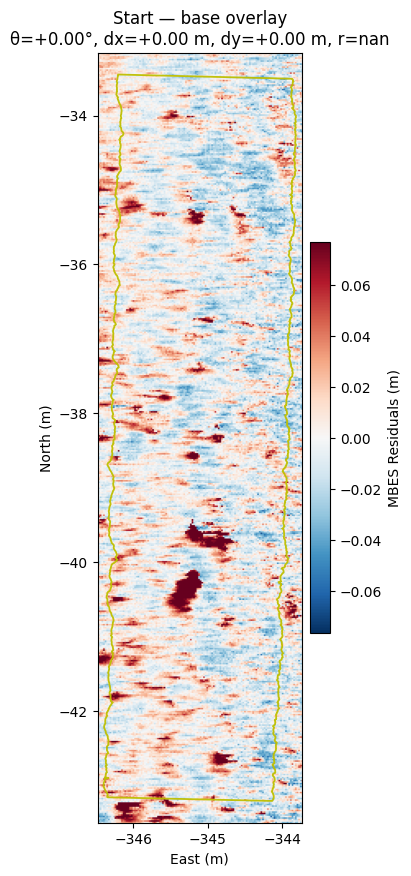

Level 1:   0%|          | 0/63 [00:00<?, ?try/s]

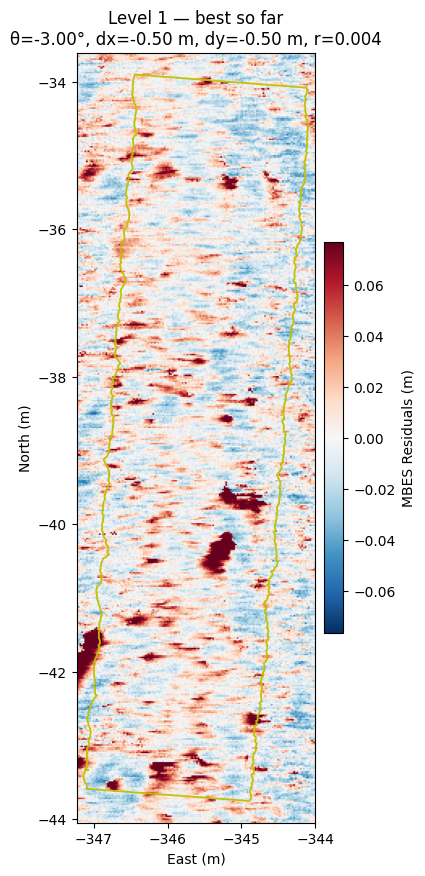

Level 1:  10%|▉         | 6/63 [02:34<24:27, 25.74s/try, acc=100.0%, best=0.004, level=0.004, pairs=28184]

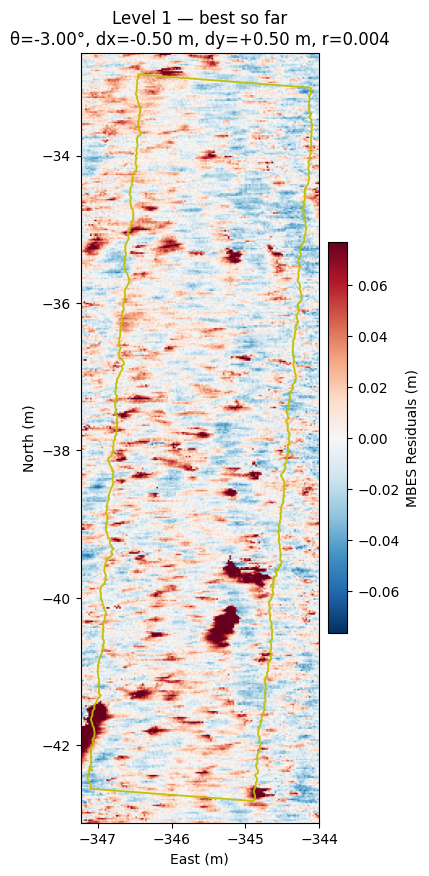

Level 1:  11%|█         | 7/63 [02:59<23:49, 25.53s/try, acc=100.0%, best=0.004, level=0.004, pairs=28171]

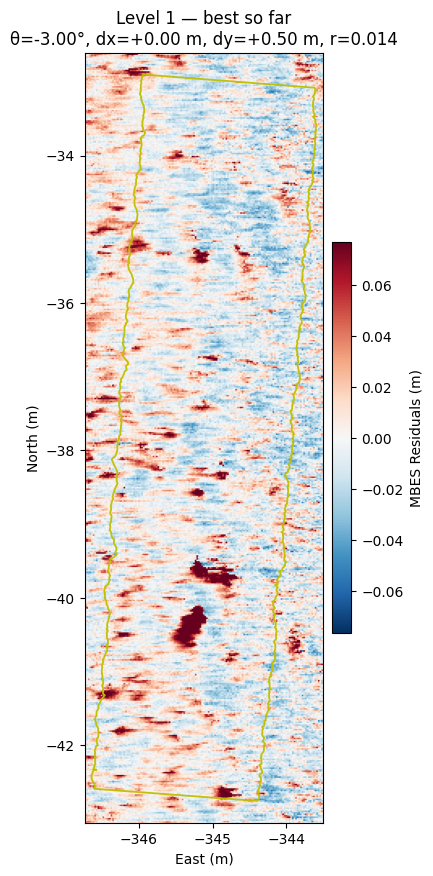

Level 1:  84%|████████▍ | 53/63 [23:39<04:39, 27.92s/try, acc=100.0%, best=0.014, level=0.014, pairs=28204]

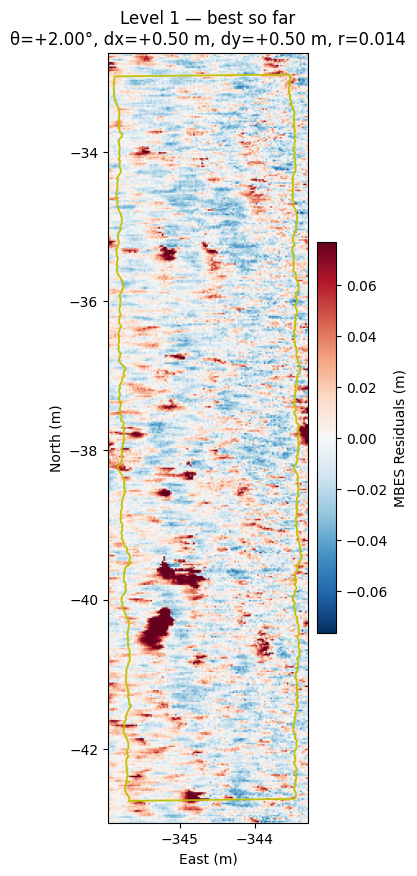

Level 1:  98%|█████████▊| 62/63 [28:30<00:32, 32.24s/try, acc=100.0%, best=0.014, level=0.014, pairs=28191]

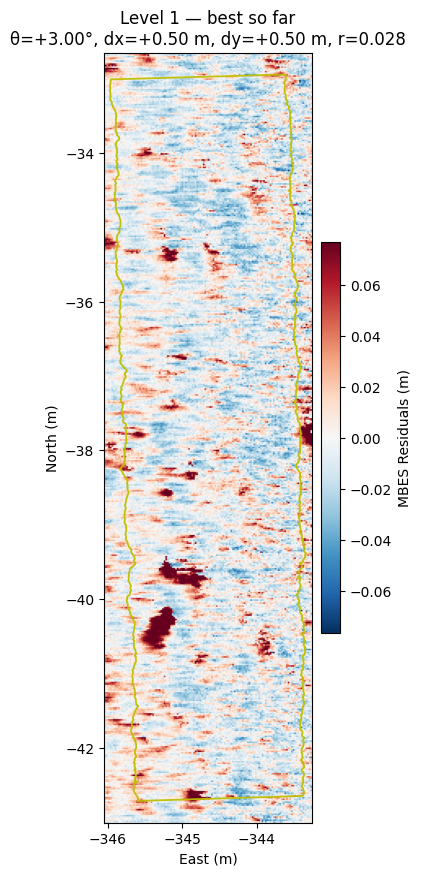

Level 1: 100%|██████████| 63/63 [29:05<00:00, 27.70s/try, acc=100.0%, best=0.028, level=0.028, pairs=28170]


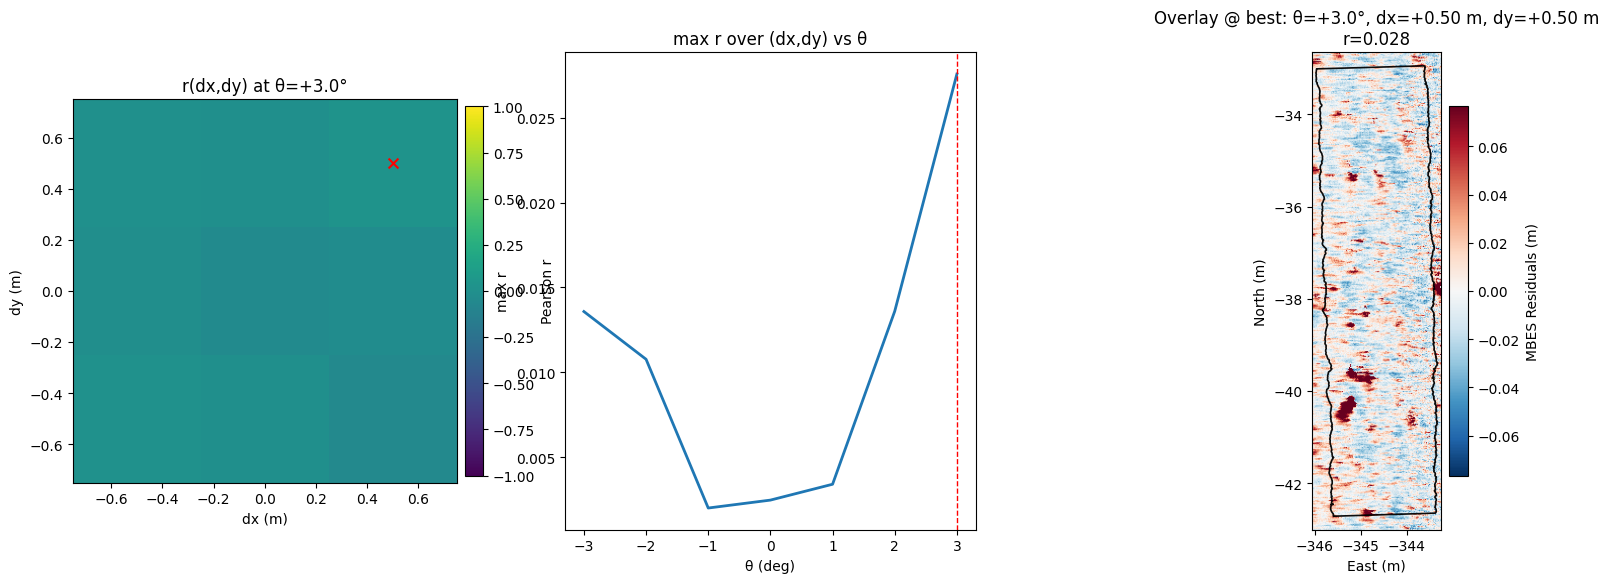

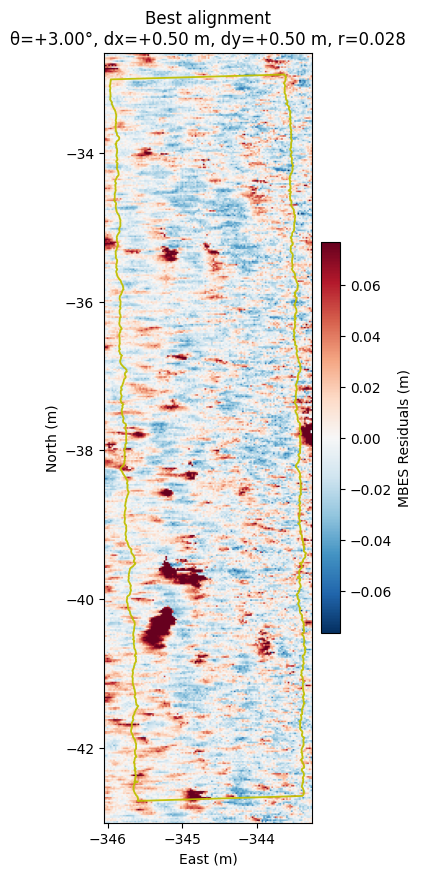


Final verdict: r=0.028  θ=+3.00°, dx=+0.50 m, dy=+0.50 m, pairs=28170

BEST: {'score': 0.027566492042618435, 'theta': 3.0, 'dx': 0.5, 'dy': 0.5, 'n': 28170, 'level': 1}


In [7]:
# run_alignment.py

# For immediate visual feedback during the search, set viz_every=1
# For very quick smoke-tests, use default_levels_tiny(); then switch to small/medium.
best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv="./alignment_search_log.csv",
    levels=default_levels_small(),  # try: default_levels_tiny(), default_levels_medium()
    gates=default_gates_small(),
    metric="pearson",
    viz_every=1,  # show overlay every improvement
    show_progress=True,  # tqdm with best/level/acc/pairs
    show_final=True,  # final overlay
    plot_each_level=True,  # 3-panel level summary
    rng_seed=0,
)

print("BEST:", best)

# try again with new version

In [8]:
# alignment_module.py
# UHI ↔ MBES alignment using BAND-AVERAGED illumination (mean across all corrected bands).
# Clean structure, progress bar, per-level summary plots, CSV logging.

from __future__ import annotations
import os
import csv
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation, spearmanr
from pyproj import Transformer
import rasterio

# Your repo modules
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# ----------------- small helpers -----------------
def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    vmax = np.quantile(np.abs(finite), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac: float = 0.03, equal_aspect: bool = True) -> None:
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """EXACT jagged outline including outer edges."""
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left/right
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top/bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []

    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)

        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    return loops


def compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# --------------- MBES detrending ---------------
@dataclass
class MBESDetrender:# runner cell — minimal call

# Quick smoke test:
# levels = default_levels_tiny()

# Small default (~63 tries; fast):
levels = default_levels_small()
gates = default_gates_small()

best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv="./alignment_search_log.csv",
    levels=levels,
    gates=gates,
    metric="pearson",   # or "spearman"
    use_abs=False,      # True if you care about |r| only
    viz_every=10,       # overlay preview every N accepted candidates
    show_progress=True, # tqdm bar with live best/acc rate
    show_final=True,
    rng_seed=0,
)

print("BEST:", best)

    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)

        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)

        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x: int = 2, robust: bool = True, central_frac: float = 0.8, max_row_iters: int = 3):
        if self.data is None:
            self.load()

        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)

            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)

            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0

            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr: np.ndarray, scale_m: float) -> np.ndarray:
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)

        self.trend = trend
        self.residuals = z - trend
        return self

    def robust_sym_vlim(self, arr: Optional[np.ndarray] = None, q: float = 0.98) -> Tuple[float, float]:
        a = self.residuals if arr is None else arr
        return robust_sym_vlim(a, q=q)


# --------------- search specs ---------------
@dataclass
class LevelSpec:
    theta_range: Tuple[float, float]
    theta_step: float
    dx_range: Tuple[float, float]
    dy_range: Tuple[float, float]
    step_xy: float
    stride: int = 1
    k: int = 1
    sample_frac: float = 1.0
    max_tries: Optional[int] = None


@dataclass
class GateSpec:
    min_pairs: int = 1000
    min_score: float = -0.25
    stop_if_score_ge: float = 0.35


# --------------- alignment search ---------------
class AlignmentSearch:
    def __init__(
        self,
        E: np.ndarray,
        N: np.ndarray,
        mask_valid: np.ndarray,
        uhi_scalar: np.ndarray,
        mb: MBESDetrender,
        lat0: float,
        lon0: float,
        h0: float,
        metric: str = "pearson",
        use_abs: bool = False,
    ):
        """
        uhi_scalar: (T,S) band-averaged illumination (mean across all corrected bands).
        """
        self.E = E
        self.N = N
        self.mask_valid = mask_valid.astype(bool)
        self.uhi_scalar = uhi_scalar
        self.metric = metric.lower()
        self.use_abs = bool(use_abs)

        # footprint path (pixel-perfect)
        Xc, Yc = pcolormesh_pad(E, N)
        segs_xy, segs_idx = boundary_segments_from_mask(self.mask_valid, Xc, Yc)
        loops = trace_loops_from_segments(segs_idx)
        self.footprint_path0 = compound_path_from_loops(loops, Xc, Yc)
        self.outline_lc = LineCollection(segs_xy, colors="k", linewidths=1.1, alpha=0.9)

        # UHI KDTree (valid pixels)
        valid_uhi = self.mask_valid & np.isfinite(uhi_scalar) & np.isfinite(E) & np.isfinite(N)
        self.uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        self.uhi_vals = uhi_scalar[valid_uhi]
        if self.uhi_pts.size == 0:
            raise RuntimeError("No valid UHI points for KDTree.")
        self.tree_uhi = cKDTree(self.uhi_pts)

        # pivot (geometric center)
        self.cx = float(np.nanmean(E[valid_uhi]))
        self.cy = float(np.nanmean(N[valid_uhi]))

        # MBES → NED (once)
        MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
        epsg_src = getattr(mb, "epsg", 32633) if getattr(mb, "epsg", None) else 32633
        tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
        mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
        tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
            mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
        )
        mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
            mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
        )
        self.mbes_e = mbes_e_ned
        self.mbes_n = mbes_n_ned
        self.mbes_res = mb.residuals
        self.P_mbes = np.column_stack([self.mbes_e.ravel(), self.mbes_n.ravel()])

        base_inside = self.footprint_path0.contains_points(self.P_mbes)
        self.base_pairs = int(np.sum(base_inside))
        if self.base_pairs == 0:
            raise RuntimeError("No MBES pixels inside UHI footprint at base.")

        self.last_level = None

    @staticmethod
    def _pearson_r(x: np.ndarray, y: np.ndarray) -> float:
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10:
            return np.nan
        x = x[m]
        y = y[m]
        sx = x.std(ddof=1)
        sy = y.std(ddof=1)
        if sx == 0 or sy == 0:
            return np.nan
        x = (x - x.mean()) / sx
        y = (y - y.mean()) / sy
        return float(np.clip(np.corrcoef(x, y)[0, 1], -1, 1))

    @staticmethod
    def _spearman_r(x: np.ndarray, y: np.ndarray) -> float:
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10:
            return np.nan
        r = spearmanr(x[m], y[m], nan_policy="omit").correlation
        return float(np.clip(r, -1, 1)) if np.isfinite(r) else np.nan

    def _score_vec(self, u: np.ndarray, z: np.ndarray) -> float:
        if self.metric == "spearman":
            r = self._spearman_r(u, z)
        else:
            r = self._pearson_r(u, z)
        return abs(r) if self.use_abs and np.isfinite(r) else r

    def score_one(self, theta_deg: float, dx: float, dy: float, stride: int, k: int, min_pairs: int) -> Tuple[float, int]:
        rad = np.deg2rad(theta_deg)
        c, s = np.cos(rad), np.sin(rad)
        Rinv = np.array([[c, s], [-s, c]], float)

        P = self.P_mbes[::stride]
        Pprime = (P - np.array([dx, dy])) - np.array([self.cx, self.cy])
        Pprime = Pprime @ Rinv.T + np.array([self.cx, self.cy])

        inside = self.footprint_path0.contains_points(Pprime)
        if not inside.any():
            return np.nan, 0
        idx_inside = np.where(inside)[0]
        if idx_inside.size < min_pairs:
            return np.nan, int(idx_inside.size)

        d, nn = self.tree_uhi.query(Pprime[idx_inside], k=k)
        u = self.uhi_vals[nn].astype(float).ravel()
        z = self.mbes_res.ravel()[::stride][idx_inside].astype(float).ravel()
        return self._score_vec(u, z), int(idx_inside.size)

    def run(
        self,
        levels: List[LevelSpec],
        gates: GateSpec,
        log_csv: Optional[str] = None,
        viz_every: int = 0,
        show_progress: bool = True,
        show_final: bool = True,
        rng_seed: int = 0,
    ) -> Dict:
        writer = None
        f_csv = None
        if log_csv:
            exists = os.path.exists(log_csv)
            f_csv = open(log_csv, "a", newline="")
            writer = csv.writer(f_csv)
            if not exists:
                writer.writerow(
                    ["ts", "level", "theta_deg", "dx_m", "dy_m", "stride", "k", "pairs", "score", "metric", "abs"]
                )

        best = {"score": -np.inf, "theta": 0.0, "dx": 0.0, "dy": 0.0, "n": 0, "level": -1}

        try:
            from tqdm import tqdm
            have_tqdm = True
        except Exception:
            have_tqdm = False

        rng = np.random.default_rng(rng_seed)

        try:
            for li, lvl in enumerate(levels, 1):
                th_vals = np.arange(lvl.theta_range[0], lvl.theta_range[1] + 1e-9, lvl.theta_step)
                dx_vals = np.arange(lvl.dx_range[0], lvl.dx_range[1] + 1e-9, lvl.step_xy)
                dy_vals = np.arange(lvl.dy_range[0], lvl.dy_range[1] + 1e-9, lvl.step_xy)

                nth, ndx, ndy = len(th_vals), len(dx_vals), len(dy_vals)
                r_cube = np.full((nth, ndy, ndx), np.nan, dtype=float)

                grid = np.array(np.meshgrid(th_vals, dy_vals, dx_vals, indexing="ij"))
                combos = grid.reshape(3, -1).T
                n_total = combos.shape[0]
                sel_idx = np.arange(n_total)

                if 0 < lvl.sample_frac < 1.0:
                    n_pick = max(1, int(np.floor(n_total * lvl.sample_frac)))
                    sel_idx = rng.choice(sel_idx, size=n_pick, replace=False)
                if lvl.max_tries is not None:
                    sel_idx = sel_idx[: int(lvl.max_tries)]
                combos = combos[sel_idx]
                n_eval = combos.shape[0]

                pbar = tqdm(total=n_eval, desc=f"Level {li}", unit="try") if (have_tqdm and show_progress) else None
                level_best = -np.inf
                accepted = 0

                def idx_th(val):
                    return int(np.round((val - th_vals[0]) / (th_vals[1] - th_vals[0] if len(th_vals) > 1 else 1)))

                def idx_dx(val):
                    return int(np.round((val - dx_vals[0]) / (dx_vals[1] - dx_vals[0] if len(dx_vals) > 1 else 1)))

                def idx_dy(val):
                    return int(np.round((val - dy_vals[0]) / (dy_vals[1] - dy_vals[0] if len(dy_vals) > 1 else 1)))

                for j, (th, dy, dx) in enumerate(combos, 1):
                    score, pairs = self.score_one(float(th), float(dx), float(dy), lvl.stride, lvl.k, gates.min_pairs)
                    try:
                        r_cube[idx_th(th), idx_dy(dy), idx_dx(dx)] = score
                    except Exception:
                        pass

                    if writer:
                        writer.writerow(
                            [
                                time.time(),
                                li,
                                float(th),
                                float(dx),
                                float(dy),
                                lvl.stride,
                                lvl.k,
                                pairs,
                                score,
                                self.metric,
                                int(self.use_abs),
                            ]
                        )

                    if np.isfinite(score):
                        accepted += 1
                        if score > level_best:
                            level_best = score
                        if score > best["score"]:
                            best.update(
                                {
                                    "score": float(score),
                                    "theta": float(th),
                                    "dx": float(dx),
                                    "dy": float(dy),
                                    "n": int(pairs),
                                    "level": li,
                                }
                            )
                            if viz_every and (accepted % max(1, int(viz_every)) == 0):
                                self._quick_viz(best, title=f"Level {li} — best so far")

                    if pbar:
                        acc_rate = 100.0 * accepted / j
                        pbar.set_postfix(
                            best=f"{best['score']:.3f}",
                            level=f"{level_best:.3f}",
                            acc=f"{acc_rate:.1f}%",
                            pairs=pairs,
                        )
                        pbar.update(1)

                if pbar:
                    pbar.close()

                self.last_level = {
                    "r_cube": r_cube,
                    "th_vals": th_vals,
                    "dx_vals": dx_vals,
                    "dy_vals": dy_vals,
                    "level_best": float(level_best),
                }

                self._plot_level_summary()

                if accepted == 0:
                    print(f"• Early stop after Level {li}: no candidates reached min_pairs={gates.min_pairs}.")
                    break
                if level_best < gates.min_score:
                    print(f"• Early stop after Level {li}: level-best {self.metric}<{gates.min_score:.2f}.")
                    break
                if best["score"] >= gates.stop_if_score_ge:
                    print(f"• Early stop: {self.metric}≥{gates.stop_if_score_ge:.2f} at Level {li}.")
                    break

            if show_final:
                self._quick_viz(best, title="Best alignment")

        finally:
            if f_csv:
                f_csv.close()

        return best

    # ---------- quick visual ----------
    def _quick_viz(self, best: Dict, title: str = ""):
        rad = np.deg2rad(best["theta"])
        c, s = np.cos(rad), np.sin(rad)
        R = np.array([[c, -s], [s, c]], float)
        dx0, dy0 = best["dx"], best["dy"]

        verts = self.footprint_path0.vertices.copy()
        mask = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
        V = verts[mask]
        V2 = (V - np.array([self.cx, self.cy])) @ R.T + np.array([self.cx, self.cy]) + np.array([dx0, dy0])
        verts[mask] = V2
        footprint_path_best = MplPath(verts, self.footprint_path0.codes)

        vmin_mbes, vmax_mbes = robust_sym_vlim(self.mbes_res, q=0.98)
        fig, ax = plt.subplots(1, 1, figsize=(5.8, 10))
        extent_ned = [
            float(np.nanmin(self.mbes_e)),
            float(np.nanmax(self.mbes_e)),
            float(np.nanmin(self.mbes_n)),
            float(np.nanmax(self.mbes_n)),
        ]
        im = ax.imshow(
            np.ma.masked_invalid(self.mbes_res),
            extent=extent_ned,
            origin="upper",
            cmap="RdBu_r",
            vmin=vmin_mbes,
            vmax=vmax_mbes,
        )
        ax.add_patch(
            PathPatch(footprint_path_best, transform=ax.transData, facecolor="none", edgecolor="y", lw=1.3, alpha=0.95)
        )
        ax.set_title(
            f"{title}\nθ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, {self.metric}={best['score']:.3f}"
            + (" (|r|)" if self.use_abs else "")
        )
        ax.set_xlabel("East (m)")
        ax.set_ylabel("North (m)")
        pad_limits(
            ax,
            footprint_path_best.vertices[:, 0].min(),
            footprint_path_best.vertices[:, 0].max(),
            footprint_path_best.vertices[:, 1].min(),
            footprint_path_best.vertices[:, 1].max(),
            pad_frac=0.03,
            equal_aspect=True,
        )
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label="MBES Residuals (m)")
        plt.show()

    def _plot_level_summary(self) -> None:
        L = self.last_level
        if L is None:
            return

        r_cube = L["r_cube"]
        th_vals = L["th_vals"]
        dx_vals = L["dx_vals"]
        dy_vals = L["dy_vals"]

        r_vs_theta = np.nanmax(r_cube, axis=(1, 2))
        if not np.isfinite(r_vs_theta).any():
            print("Level summary: no finite scores.")
            return

        it_best = int(np.nanargmax(r_vs_theta))
        th_best = th_vals[it_best]
        R_slice = r_cube[it_best, :, :]

        j_best, i_best = np.unravel_index(int(np.nanargmax(R_slice)), R_slice.shape)
        dx_best = dx_vals[i_best]
        dy_best = dy_vals[j_best]
        r_best = float(R_slice[j_best, i_best])

        fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
        axA, axB, axC = axes

        dx_step = dx_vals[1] - dx_vals[0] if len(dx_vals) > 1 else 1.0
        dy_step = dy_vals[1] - dy_vals[0] if len(dy_vals) > 1 else 1.0
        imA = axA.imshow(
            R_slice,
            origin="lower",
            extent=[
                dx_vals[0] - 0.5 * dx_step,
                dx_vals[-1] + 0.5 * dx_step,
                dy_vals[0] - 0.5 * dy_step,
                dy_vals[-1] + 0.5 * dy_step,
            ],
            cmap="viridis",
            vmin=-1,
            vmax=1,
            aspect="equal",
        )
        axA.scatter([dx_best], [dy_best], c="r", s=50, marker="x", zorder=5)
        axA.set_title(f"{self.metric} (dx,dy) @ θ={th_best:+.1f}°")
        axA.set_xlabel("dx (m)")
        axA.set_ylabel("dy (m)")
        fig.colorbar(imA, ax=axA, fraction=0.045, pad=0.02, label=self.metric + (" (abs)" if self.use_abs else ""))

        axB.plot(th_vals, r_vs_theta, lw=2)
        axB.axvline(th_best, color="r", ls="--", lw=1)
        axB.set_title(f"max {self.metric} over (dx,dy) vs θ")
        axB.set_xlabel("θ (deg)")
        axB.set_ylabel(f"max {self.metric}")

        axC.axis("off")
        axC.text(
            0.02,
            0.98,
            f"Best slice θ={th_best:+.1f}°\n"
            f"Best (dx,dy)=({dx_best:+.2f},{dy_best:+.2f}) m\n"
            f"Best {self.metric}={r_best:.3f}",
            va="top",
            ha="left",
            fontsize=12,
        )
        plt.show()


# --------------- defaults ---------------
def default_levels_small() -> List[LevelSpec]:
    # ~63 tries (fast)
    return [
        LevelSpec(
            theta_range=(-3.0, 3.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=2,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_levels_tiny() -> List[LevelSpec]:
    # very fast smoke test
    return [
        LevelSpec(
            theta_range=(-1.0, 1.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=4,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_gates_small() -> GateSpec:
    return GateSpec(min_pairs=1000, min_score=-0.25, stop_if_score_ge=0.35)


# --------------- orchestration (uses BAND-AVERAGED UHI) ---------------
def auto_align_from_config(
    file_ids: List[str],
    track_start: int,
    track_end: int,
    log_csv: Optional[str],
    levels: List[LevelSpec],
    gates: GateSpec,
    metric: str = "pearson",
    use_abs: bool = False,
    viz_every: int = 10,
    show_progress: bool = True,
    show_final: bool = True,
    rng_seed: int = 0,
) -> Tuple[Dict, AlignmentSearch]:
    """
    Loads UHI, applies illumination correction, computes BAND-AVERAGED UHI image (mean across bands),
    detrends MBES, then runs alignment search.
    """
    # --- UHI load/slice ---
    transect = georef.load_transect(config.OUTPUT_FOLDER)
    cube = transect.select_files(file_ids)

    X = cube.X_ecef[track_start:track_end, :]
    Y = cube.Y_ecef[track_start:track_end, :]
    Z = cube.Z_ecef[track_start:track_end, :]
    R = cube.R[track_start:track_end, :]
    G = cube.G[track_start:track_end, :]
    B = cube.B[track_start:track_end, :]

    full_valid = build_full_valid(X, Y, Z, R, G, B)

    lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
    N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)

    # --- Illumination correction (persistent) ---
    cube.apply_illumination_correction(window_size=1000, strength=1.0)
    # BAND-AVERAGED (mean across all corrected bands) for the chosen slice
    uhi_scalar = np.nanmean(cube.data_corrected[track_start:track_end, :, :], axis=2).astype(np.float32)

    # --- MBES detrend ---
    mb = MBESDetrender(
        config.MBES_GEOTIFF,
        smooth_baseline_m=0.5,
        smooth_tilt_m=0.5,
        smooth_center_m=1.0,
    ).load().detrend(order_x=2, robust=True, central_frac=0.8)

    # --- Align ---
    print(f"Start — base UHI valid pixels: {int(full_valid.sum()):,}")
    aligner = AlignmentSearch(
        E=E,
        N=N,
        mask_valid=full_valid,
        uhi_scalar=uhi_scalar,
        mb=mb,
        lat0=lat0,
        lon0=lon0,
        h0=h0,
        metric=metric,
        use_abs=use_abs,
    )
    best = aligner.run(
        levels=levels,
        gates=gates,
        log_csv=log_csv,
        viz_every=viz_every,
        show_progress=show_progress,
        show_final=show_final,
        rng_seed=rng_seed,
    )
    print(
        f"\nFinal verdict: {metric}={best['score']:.3f}  "
        f"θ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, pairs={best['n']}"
    )
    return best, aligner


In [ ]:
# runner cell — minimal call

# Quick smoke test:
# levels = default_levels_tiny()

# Small default (~63 tries; fast):
levels = default_levels_small()
gates = default_gates_small()

best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv="./alignment_search_log.csv",
    levels=levels,
    gates=gates,
    metric="pearson",  # or "spearman"
    use_abs=False,  # True if you care about |r| only
    viz_every=10,  # overlay preview every N accepted candidates
    show_progress=True,  # tqdm bar with live best/acc rate
    show_final=True,
    rng_seed=0,
)

print("BEST:", best)

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
Start — base UHI valid pixels: 958,320


Level 1:  29%|██▊       | 18/63 [11:34<28:49, 38.44s/try, acc=100.0%, best=0.007, level=0.007, pairs=28152] 

add correlation plots

In [1]:
# alignment_module.py
# Compact utilities to (1) build UHI/MBES comparables, (2) run a rigid alignment
# grid-search with user-specified ranges/steps, and (3) plot a density scatter
# showing the correlation at the best alignment.
from __future__ import annotations
import os
import sys
from dataclasses import dataclass
from typing import Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from pyproj import Transformer
from tqdm import tqdm
import rasterio

# --- setup path for repo imports ---
sys.path.append(os.path.abspath("../"))

# --- repo imports (assumed available in your notebook/kernel) ---
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# small helpers
# -----------------------------
def robust_z(a: np.ndarray) -> np.ndarray:
    m = np.isfinite(a)
    if not m.any():
        return np.full_like(a, np.nan, float)
    med = np.nanmedian(a[m])
    mad = median_abs_deviation(a[m], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - med) / mad


def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    x = np.asarray(arr)
    f = np.isfinite(x)
    if not f.any():
        return (-1.0, 1.0)
    lo, hi = np.nanquantile(x[f], [(1 - q) / 2, 1 - (1 - q) / 2])
    vmax = max(abs(lo), abs(hi))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = (np.nanstd(x[f]) or 1.0) * 3
    return (-vmax, vmax)


def _savgol_nanaware(arr, window_length, polyorder=2):
    a = np.asarray(arr, float)
    valid = np.isfinite(a)
    if valid.sum() < max(3, window_length):
        return a.copy()
    if window_length < polyorder + 2:
        window_length = polyorder + 2
    if window_length % 2 == 0:
        window_length += 1
    filled = a.copy()
    if (~valid).any():
        idx = np.arange(filled.size)
        filled[~valid] = np.interp(idx[~valid], idx[valid], filled[valid])
    smoothed = savgol_filter(filled, window_length, polyorder, mode="interp")
    smoothed[~valid] = np.nan
    return smoothed


# -----------------------------
# MBESDetrender
# -----------------------------
@dataclass
class MBESDetrender:
    """
    Lightweight detrending for MBES bathymetry to remove large-scale slopes.
    """

    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 10.0
    smooth_tilt_m: float = 20.0
    smooth_curv_m: Optional[float] = None
    smooth_center_m: float = 6.0
    max_row_iters: int = 3
    clip_sigma: float = 6.0
    central_frac: float = 0.8
    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    A: Optional[np.ndarray] = None
    B: Optional[np.ndarray] = None
    C: Optional[np.ndarray] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    x_center_row: Optional[np.ndarray] = None
    x_center_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            b = src.bounds
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        self.data = z
        self.transform = tf
        self.extent = (float(b.left), float(b.right), float(b.bottom), float(b.top))
        a, _, c, _, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        return self

    def detrend(
        self,
        order_x: int = 2,
        remove_cross_track_tilt: bool = True,
        robust: bool = True,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        smooth_curv_m: Optional[float] = None,
        smooth_center_m: Optional[float] = None,
        central_frac: Optional[float] = None,
    ):
        if self.data is None:
            self.load()
        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)
        if smooth_curv_m is not None:
            self.smooth_curv_m = float(smooth_curv_m)
        if smooth_center_m is not None:
            self.smooth_center_m = float(smooth_center_m)
        if central_frac is not None:
            self.central_frac = float(central_frac)
        if self.smooth_curv_m is None:
            self.smooth_curv_m = self.smooth_tilt_m

        Z = self.data
        x = self.x_cols
        H, W = Z.shape
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        x_center = np.full(H, np.nan)

        for i in range(H):
            row = Z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            x_center[i] = xc_row

            if 0 < self.central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * self.central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * self.central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = (
                2
                if (order_x >= 2 and remove_cross_track_tilt)
                else (1 if remove_cross_track_tilt else 0)
            )
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(self.max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    XtW = X * w
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])

            A[i] = a0
            B[i] = a1 if remove_cross_track_tilt else 0.0
            C[i] = a2 if (order_x >= 2 and remove_cross_track_tilt) else 0.0

        def _clip_and_fill(arr):
            s = arr.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            mu, std = np.nanmean(s[m]), np.nanstd(s[m])
            good = m & (np.abs(s - mu) < self.clip_sigma * std)
            if good.sum() < 3:
                return s
            idx = np.arange(s.size)
            if (~good).any():
                s[~good] = np.interp(idx[~good], idx[good], s[good])
            return s

        A = _clip_and_fill(A)
        B = _clip_and_fill(B)
        C = _clip_and_fill(C)
        x_center = _clip_and_fill(x_center)

        def _nwin(meters, poly=2):
            n = max(5, int(round(meters / max(abs(self.px_y), 1e-9))))
            if n % 2 == 0:
                n += 1
            if n <= poly + 2:
                n = poly + 3 if (poly + 3) % 2 == 1 else poly + 4
            return n

        A_s = _savgol_nanaware(A, _nwin(self.smooth_baseline_m), 2)
        B_s = _savgol_nanaware(B, _nwin(self.smooth_tilt_m), 2)
        C_s = _savgol_nanaware(C, _nwin(self.smooth_curv_m), 2)
        Xc = _savgol_nanaware(x_center, _nwin(self.smooth_center_m), 2)

        xi_grid = self.x_cols[None, :] - Xc[:, None]
        trend = A_s[:, None] + B_s[:, None] * xi_grid + C_s[:, None] * (xi_grid**2)
        if self.valid_mask is not None:
            trend = np.where(self.valid_mask, trend, np.nan)
        resid = self.data - trend
        resid[~np.isfinite(self.data)] = np.nan

        self.A, self.B, self.C = A, B, C
        self.A_s, self.B_s, self.C_s = A_s, B_s, C_s
        self.x_center_row, self.x_center_s = x_center, Xc
        self.trend, self.residuals = trend, resid
        return self


# -----------------------------
# AlignmentSearch
# -----------------------------
@dataclass
class LevelSpec:
    dE_range: Tuple[float, float]
    dN_range: Tuple[float, float]
    dZ_range: Tuple[float, float]
    dE_step: float
    dN_step: float
    dZ_step: float


@dataclass
class GateSpec:
    max_dist_m: float = 1.0
    outlier_z: float = 3.0
    min_pairs: int = 50


class AlignmentSearch:
    """
    Multi-level grid search for (dE, dN, dZ) alignment between UHI intensity
    and detrended MBES depth.
    """

    def __init__(
        self,
        uhi_x_utm: np.ndarray,
        uhi_y_utm: np.ndarray,
        uhi_z_ned: np.ndarray,
        uhi_intensity: np.ndarray,
        mbes_x_utm: np.ndarray,
        mbes_y_utm: np.ndarray,
        mbes_depth_residual: np.ndarray,
        levels: List[LevelSpec],
        gate: GateSpec = GateSpec(),
        normalize_intensity: bool = True,
        normalize_mbes: bool = True,
        verbose: bool = True,
    ):
        self.uhi_x = uhi_x_utm
        self.uhi_y = uhi_y_utm
        self.uhi_z = uhi_z_ned
        self.uhi_I = uhi_intensity
        self.mbes_x = mbes_x_utm
        self.mbes_y = mbes_y_utm
        self.mbes_res = mbes_depth_residual
        self.levels = levels
        self.gate = gate
        self.norm_I = normalize_intensity
        self.norm_M = normalize_mbes
        self.verbose = verbose
        self.history: List[Dict] = []
        self.best_params: Optional[Dict] = None
        self.best_score: Optional[float] = None

    def run(self):
        dE, dN, dZ = 0.0, 0.0, 0.0
        for lvl_idx, lvl in enumerate(self.levels):
            if self.verbose:
                print(f"\n--- Level {lvl_idx + 1}/{len(self.levels)} ---")
            cands = self._build_grid(lvl, dE, dN, dZ)
            if self.verbose:
                print(f"Grid has {len(cands)} candidates.")
            best_c, best_s = None, None
            for c in tqdm(cands, disable=not self.verbose):
                s = self._evaluate(c["dE"], c["dN"], c["dZ"])
                if np.isfinite(s):
                    self.history.append({**c, "score": s, "level": lvl_idx + 1})
                    if best_s is None or s < best_s:
                        best_c, best_s = c, s
            if best_c is None:
                if self.verbose:
                    print("No valid alignment found at this level.")
                break
            dE, dN, dZ = best_c["dE"], best_c["dN"], best_c["dZ"]
            if self.verbose:
                print(
                    f"Best at level {lvl_idx + 1}: dE={dE:.3f}, dN={dN:.3f}, dZ={dZ:.3f}, score={best_s:.6f}"
                )
        self.best_params = {"dE": dE, "dN": dN, "dZ": dZ}
        self.best_score = best_s
        return self.best_params, self.best_score

    def _build_grid(self, lvl: LevelSpec, cE, cN, cZ):
        dE_vals = np.arange(
            cE + lvl.dE_range[0], cE + lvl.dE_range[1] + 1e-9, lvl.dE_step
        )
        dN_vals = np.arange(
            cN + lvl.dN_range[0], cN + lvl.dN_range[1] + 1e-9, lvl.dN_step
        )
        dZ_vals = np.arange(
            cZ + lvl.dZ_range[0], cZ + lvl.dZ_range[1] + 1e-9, lvl.dZ_step
        )
        out = []
        for dE in dE_vals:
            for dN in dN_vals:
                for dZ in dZ_vals:
                    out.append({"dE": float(dE), "dN": float(dN), "dZ": float(dZ)})
        return out

    def _evaluate(self, dE, dN, dZ):
        x_shift = self.uhi_x + dE
        y_shift = self.uhi_y + dN
        z_shift = self.uhi_z + dZ
        tree = cKDTree(np.c_[self.mbes_x, self.mbes_y])
        dists, idxs = tree.query(np.c_[x_shift, y_shift], k=1)
        close = dists <= self.gate.max_dist_m
        if close.sum() < self.gate.min_pairs:
            return np.nan
        uI = self.uhi_I[close]
        mR = self.mbes_res[idxs[close]]
        if self.norm_I:
            uI = robust_z(uI)
        if self.norm_M:
            mR = robust_z(mR)
        diff = uI - mR
        good = np.isfinite(diff)
        if good.sum() < self.gate.min_pairs:
            return np.nan
        diff = diff[good]
        if self.gate.outlier_z > 0:
            mu, sig = np.mean(diff), np.std(diff)
            keep = np.abs(diff - mu) <= self.gate.outlier_z * sig
            if keep.sum() < self.gate.min_pairs:
                return np.nan
            diff = diff[keep]
        return float(np.std(diff))

    def plot_correlation(self, dE=None, dN=None, dZ=None, title_suffix="", show=True):
        if dE is None:
            dE = self.best_params["dE"]
        if dN is None:
            dN = self.best_params["dN"]
        if dZ is None:
            dZ = self.best_params["dZ"]
        x_shift = self.uhi_x + dE
        y_shift = self.uhi_y + dN
        z_shift = self.uhi_z + dZ
        tree = cKDTree(np.c_[self.mbes_x, self.mbes_y])
        dists, idxs = tree.query(np.c_[x_shift, y_shift], k=1)
        close = dists <= self.gate.max_dist_m
        if close.sum() < self.gate.min_pairs:
            print("Not enough pairs for correlation plot.")
            return None
        uI = self.uhi_I[close]
        mR = self.mbes_res[idxs[close]]
        if self.norm_I:
            uI_plot = robust_z(uI)
        else:
            uI_plot = uI.copy()
        if self.norm_M:
            mR_plot = robust_z(mR)
        else:
            mR_plot = mR.copy()
        good = np.isfinite(uI_plot) & np.isfinite(mR_plot)
        if good.sum() < self.gate.min_pairs:
            print("Not enough valid pairs after normalization.")
            return None
        uI_plot = uI_plot[good]
        mR_plot = mR_plot[good]
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))
        ax.hexbin(mR_plot, uI_plot, gridsize=50, cmap="viridis", mincnt=1)
        ax.set_xlabel("MBES residual (normalized)" if self.norm_M else "MBES residual")
        ax.set_ylabel("UHI intensity (normalized)" if self.norm_I else "UHI intensity")
        corr = np.corrcoef(mR_plot, uI_plot)[0, 1]
        ax.set_title(
            f"UHI ↔ MBES Correlation\ndE={dE:.2f}, dN={dN:.2f}, dZ={dZ:.2f}, r={corr:.3f}{(' — ' + title_suffix) if title_suffix else ''}",
            fontsize=10,
        )
        ax.grid(True, alpha=0.3)
        if show:
            plt.show(block=False)
        return fig


# -----------------------------
# convenience functions
# -----------------------------
def default_levels_small():
    return [
        LevelSpec(
            dE_range=(-5.0, 5.0),
            dN_range=(-5.0, 5.0),
            dZ_range=(-2.0, 2.0),
            dE_step=0.5,
            dN_step=0.5,
            dZ_step=0.2,
        ),
        LevelSpec(
            dE_range=(-0.5, 0.5),
            dN_range=(-0.5, 0.5),
            dZ_range=(-0.2, 0.2),
            dE_step=0.1,
            dN_step=0.1,
            dZ_step=0.05,
        ),
    ]


def default_gates_small():
    return GateSpec(max_dist_m=1.0, outlier_z=3.0, min_pairs=50)


def auto_align_from_config(
    h5_folder: str,
    mbes_tif: str,
    nav_csv: str,
    time_offset_sec: float,
    epsg_utm: int,
    epsg_geo: int,
    lon0: float,
    lat0: float,
    h0: float,
    levels: Optional[List[LevelSpec]] = None,
    gate: Optional[GateSpec] = None,
    uhi_band_avg: Tuple[int, int] = (20, 180),
    mbes_detrend_params: Optional[Dict] = None,
    verbose: bool = True,
):
    if levels is None:
        levels = default_levels_small()
    if gate is None:
        gate = default_gates_small()
    if mbes_detrend_params is None:
        mbes_detrend_params = dict(
            order_x=3,
            smooth_baseline_m=0.8,
            smooth_tilt_m=0.7,
            smooth_center_m=1.0,
            robust=True,
            central_frac=0.8,
        )

    # 1) Build UHI data
    uhi_x, uhi_y, uhi_z, uhi_I = georef.build_uhi_data(
        h5_folder=h5_folder,
        nav_csv=nav_csv,
        time_offset_sec=time_offset_sec,
        epsg_utm=epsg_utm,
        epsg_geo=epsg_geo,
        lon0=lon0,
        lat0=lat0,
        h0=h0,
        band_start=uhi_band_avg[0],
        band_end=uhi_band_avg[1],
    )

    # 2) Detrend MBES
    mb = MBESDetrender(mbes_tif).load().detrend(**mbes_detrend_params)
    mbes_x_utm = mb.x_cols[None, :] + np.zeros((mb.residuals.shape[0], 1))
    mbes_y_utm = mb.y_rows[:, None] + np.zeros((1, mb.residuals.shape[1]))
    mbes_res = mb.residuals
    valid = np.isfinite(mbes_res)
    mbes_x_utm = mbes_x_utm[valid]
    mbes_y_utm = mbes_y_utm[valid]
    mbes_res = mbes_res[valid]

    # 3) Run alignment
    searcher = AlignmentSearch(
        uhi_x_utm=uhi_x,
        uhi_y_utm=uhi_y,
        uhi_z_ned=uhi_z,
        uhi_intensity=uhi_I,
        mbes_x_utm=mbes_x_utm,
        mbes_y_utm=mbes_y_utm,
        mbes_depth_residual=mbes_res,
        levels=levels,
        gate=gate,
        normalize_intensity=True,
        normalize_mbes=True,
        verbose=verbose,
    )
    best, score = searcher.run()
    if verbose:
        print(f"\n=== Final best alignment ===")
        print(f"dE={best['dE']:.3f}, dN={best['dN']:.3f}, dZ={best['dZ']:.3f}")
        print(f"Score (std of normalized diff): {score:.6f}")
    return searcher, best, score

NameError: name 'sys' is not defined

running this to see if it works 


In [ ]:
# alignment_module.py
# Compact utilities to (1) build UHI/MBES comparables, (2) run a rigid alignment
# grid-search with user-specified ranges/steps, and (3) plot a density scatter
# showing the correlation at the best alignment.
from __future__ import annotations
import os
from dataclasses import dataclass
from typing import Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from pyproj import Transformer
from tqdm import tqdm
import rasterio
import sys

sys.path.append(os.path.abspath("../"))

# --- repo imports (assumed available in your notebook/kernel) ---
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# small helpers
# -----------------------------
def robust_z(a: np.ndarray) -> np.ndarray:
    m = np.isfinite(a)
    if not m.any():
        return np.full_like(a, np.nan, float)
    med = np.nanmedian(a[m])
    mad = median_abs_deviation(a[m], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - med) / mad


def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    x = np.asarray(arr)
    m = np.isfinite(x)
    if not m.any():
        return -1.0, 1.0
    vmax = np.quantile(np.abs(x[m]), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """Exact jagged outline (includes outer edges)."""
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # vertical internal
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    for i, j in zip(iv, jv + 1):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # horizontal internal
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    for i, j in zip(ih + 1, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer edges
    for i in np.nonzero(mask[:, 0])[0]:  # left
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])
    for i in np.nonzero(mask[:, -1])[0]:  # right
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])
    for j in np.nonzero(mask[0, :])[0]:  # top
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])
    for j in np.nonzero(mask[-1, :])[0]:  # bottom
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    """Turn corner-index segments into closed loops."""
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def _compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# -----------------------------
# MBES detrending (minimal)
# -----------------------------
@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: float = 9999.0

    data: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        # simple row-wise quadratic detrend (robust enough for residuals)
        H, W = z.shape
        x_cols = tf.c + tf.a * (np.arange(W) + 0.5)
        y_rows = tf.f + tf.e * (np.arange(H) + 0.5)
        self.x_cols, self.y_rows = x_cols, y_rows

        A = np.ones((W, 3))
        X0 = x_cols - np.nanmedian(x_cols)
        A[:, 1] = X0
        A[:, 2] = X0**2

        trend = np.full_like(z, np.nan)
        for i in range(H):
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() >= 6:
                beta, *_ = np.linalg.lstsq(A[m], row[m], rcond=None)
                trend[i, m] = A[m] @ beta

        self.data = z
        self.residuals = z - trend
        return self


# -----------------------------
# UHI/MBES builder
# -----------------------------
@dataclass
class UhiMbesData:
    # UHI
    E: np.ndarray
    N: np.ndarray
    mask_valid: np.ndarray
    uhi_intensity: np.ndarray  # illumination-corrected **median across bands**
    footprint_path: MplPath
    # MBES
    mb: MBESDetrender
    mbes_E: np.ndarray
    mbes_N: np.ndarray
    extent_ned: Tuple[float, float, float, float]


def build_uhi_mbes(
    file_ids,
    track_start: Optional[int] = None,
    track_end: Optional[int] = None,
) -> UhiMbesData:
    """Load UHI files, illumination-correct them, average across bands,
    build footprint, and prepare MBES residuals & NED grid."""
    # --- UHI cube ---
    transect = georef.load_transect(config.OUTPUT_FOLDER)
    cube = transect.select_files(file_ids) if file_ids else transect.select_all_files()

    # optional slice along track
    T = cube.X_ecef.shape[0]
    i0 = 0 if track_start is None else int(track_start)
    i1 = T if track_end is None else int(track_end)
    X = cube.X_ecef[i0:i1]
    Y = cube.Y_ecef[i0:i1]
    Z = cube.Z_ecef[i0:i1]
    R = cube.R[i0:i1]
    G = cube.G[i0:i1]
    B = cube.B[i0:i1]

    # NED
    lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
    N, E, _ = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
    mask_valid = build_full_valid(X, Y, Z, R, G, B)

    # illumination correction (persistent); then median across bands
    cube.apply_illumination_correction(window_size=1000, strength=1.0)
    data_corr = cube.data_corrected[i0:i1, :, :]  # (T,S,B)
    uhi_intensity = np.nanmedian(data_corr, axis=2)  # single-band intensity

    # footprint (pixel-perfect)
    Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
    segs_xy, segs_idx = _boundary_segments_from_mask(mask_valid, Xc_uhi, Yc_uhi)
    loops = _trace_loops_from_segments(segs_idx)
    footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)

    # --- MBES detrend & NED grid ---
    mb = MBESDetrender(config.MBES_GEOTIFF).load()
    mb = mb  # already detrended inside .load()

    # MBES -> lon/lat -> ECEF -> NED
    MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
    epsg_src = mb.epsg or 32633
    tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
    lon, lat = tf_to_ll.transform(MBES_X, MBES_Y)
    tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    x_ecef, y_ecef, z_ecef = tf_geo_to_ecef.transform(lon, lat, np.zeros_like(lon))
    n_ned, e_ned, _ = _ecef_to_ned_arrays(x_ecef, y_ecef, z_ecef, lat0, lon0, h0)

    extent_ned = [
        float(e_ned.min()),
        float(e_ned.max()),
        float(n_ned.min()),
        float(n_ned.max()),
    ]

    return UhiMbesData(
        E=E,
        N=N,
        mask_valid=mask_valid,
        uhi_intensity=uhi_intensity,
        footprint_path=footprint_path,
        mb=mb,
        mbes_E=e_ned,
        mbes_N=n_ned,
        extent_ned=tuple(extent_ned),
    )


# -----------------------------
# Alignment search
# -----------------------------
@dataclass
class SearchParams:
    dx_range: Tuple[float, float] = (-0.5, 0.5)  # meters
    dy_range: Tuple[float, float] = (-0.5, 0.5)  # meters
    theta_range: Tuple[float, float] = (-3.0, 3.0)  # degrees
    step_dx: float = 0.5
    step_dy: float = 0.5
    step_theta: float = 1.0
    min_overlap: int = 2000  # at least N matched pixels
    k_query: int = 1  # NN sampling
    show_progress: bool = True


def _pearson_r(x: np.ndarray, y: np.ndarray) -> float:
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 50:
        return np.nan
    xv = x[m]
    yv = y[m]
    sx = xv.std(ddof=1)
    sy = yv.std(ddof=1)
    if sx == 0 or sy == 0:
        return np.nan
    xv = (xv - xv.mean()) / sx
    yv = (yv - yv.mean()) / sy
    r = np.corrcoef(xv, yv)[0, 1]
    return float(np.clip(r, -1, 1))


def run_alignment_search(data: UhiMbesData, params: SearchParams) -> Dict:
    """Grid-search θ, dx, dy to maximize Pearson r between UHI intensity and MBES residuals."""
    # UHI KDTree
    valid_uhi = (
        data.mask_valid
        & np.isfinite(data.uhi_intensity)
        & np.isfinite(data.E)
        & np.isfinite(data.N)
    )
    uhi_pts = np.column_stack([data.E[valid_uhi], data.N[valid_uhi]])
    uhi_vals = data.uhi_intensity[valid_uhi]
    if uhi_pts.size == 0:
        return {"score": np.nan, "theta": 0.0, "dx": 0.0, "dy": 0.0, "n": 0}

    tree = cKDTree(uhi_pts)

    # MBES points (centers), flattened
    P_mbes = np.column_stack([data.mbes_E.ravel(), data.mbes_N.ravel()])

    # rotation pivot = centroid of UHI valid points
    cx = float(np.nanmean(data.E[valid_uhi]))
    cy = float(np.nanmean(data.N[valid_uhi]))

    # grids
    dx_vals = np.arange(params.dx_range[0], params.dx_range[1] + 1e-9, params.step_dx)
    dy_vals = np.arange(params.dy_range[0], params.dy_range[1] + 1e-9, params.step_dy)
    th_vals = np.arange(
        params.theta_range[0], params.theta_range[1] + 1e-9, params.step_theta
    )

    best = {"score": -np.inf, "theta": 0.0, "dx": 0.0, "dy": 0.0, "n": 0}
    total = len(dx_vals) * len(dy_vals) * len(th_vals)
    iterator = (
        tqdm(total=total, desc="Grid search (θ, dy, dx)", unit="try")
        if params.show_progress
        else None
    )

    for th in th_vals:
        rad = np.deg2rad(th)
        c, s = np.cos(rad), np.sin(rad)
        Rinv = np.array([[c, s], [-s, c]], float)  # inverse of forward rotation

        for dy0 in dy_vals:
            for dx0 in dx_vals:
                # inverse-transform MBES → base UHI frame
                Pp = (P_mbes - np.array([dx0, dy0])) - np.array([cx, cy])
                Pp = Pp @ Rinv.T + np.array([cx, cy])  # (M,2)

                # keep only MBES centers inside original UHI footprint
                inside = data.footprint_path.contains_points(Pp)
                if not inside.any():
                    if iterator:
                        iterator.update(1)
                    continue

                idx = np.where(inside)[0]
                if idx.size < params.min_overlap:
                    if iterator:
                        iterator.update(1)
                    continue

                # NN sample UHI at those Pp locations
                _, nn = tree.query(Pp[idx], k=params.k_query)
                u = uhi_vals[nn].astype(float)
                z = data.mb.residuals.ravel()[idx].astype(float)

                # compare in robust z-units (not strictly needed for r, but consistent)
                r = _pearson_r(robust_z(u), robust_z(z))
                n_pairs = int(np.isfinite(u).sum())

                if np.isfinite(r) and r > best["score"]:
                    best.update(
                        {
                            "score": float(r),
                            "theta": float(th),
                            "dx": float(dx0),
                            "dy": float(dy0),
                            "n": n_pairs,
                        }
                    )
                if iterator:
                    iterator.set_postfix(
                        best_r=f"{best['score']:.3f}",
                        th=f"{best['theta']:+.1f}°",
                        dx=f"{best['dx']:+.2f}",
                        dy=f"{best['dy']:+.2f}",
                    )
                    iterator.update(1)
    if iterator:
        iterator.close()
    return best


# -----------------------------
# Final density-scatter plot at a chosen (θ,dx,dy)
# -----------------------------
def plot_density_scatter_at(
    data: UhiMbesData,
    theta_deg: float,
    dx_m: float,
    dy_m: float,
    gridsize: int = 80,
    title: Optional[str] = None,
):
    """Build the matched pairs at a given transform and plot z(MBES) vs z(UHI) as hexbin."""
    # KDTree
    valid_uhi = (
        data.mask_valid
        & np.isfinite(data.uhi_intensity)
        & np.isfinite(data.E)
        & np.isfinite(data.N)
    )
    tree = cKDTree(np.column_stack([data.E[valid_uhi], data.N[valid_uhi]]))
    uhi_vals = data.uhi_intensity[valid_uhi]

    # rotation pivot
    cx = float(np.nanmean(data.E[valid_uhi]))
    cy = float(np.nanmean(data.N[valid_uhi]))
    P = np.column_stack([data.mbes_E.ravel(), data.mbes_N.ravel()])

    # inverse-transform MBES → base UHI frame
    rad = np.deg2rad(theta_deg)
    c, s = np.cos(rad), np.sin(rad)
    Rinv = np.array([[c, s], [-s, c]], float)
    Pp = (P - np.array([dx_m, dy_m])) - np.array([cx, cy])
    Pp = Pp @ Rinv.T + np.array([cx, cy])

    inside = data.footprint_path.contains_points(Pp)
    idx = np.where(inside)[0]
    if idx.size == 0:
        raise RuntimeError("No overlap at the requested transform.")

    _, nn = tree.query(Pp[idx], k=1)
    u = uhi_vals[nn].astype(float)
    z = data.mb.residuals.ravel()[idx].astype(float)

    zU = robust_z(u)
    zM = robust_z(z)
    m = np.isfinite(zU) & np.isfinite(zM)
    zU = zU[m]
    zM = zM[m]
    if zU.size < 50:
        raise RuntimeError("Too few valid pairs to plot.")

    # metrics
    r = _pearson_r(zM, zU)
    b, a = np.polyfit(zM, zU, 1) if zU.size > 1 else (np.nan, np.nan)

    # plot
    fig = plt.figure(figsize=(7.2, 6.0))
    ax = fig.add_subplot(111)
    hb = ax.hexbin(zM, zU, gridsize=gridsize, mincnt=1, cmap="viridis")
    lim = float(
        np.clip(np.nanmax(np.abs([zM.min(), zM.max(), zU.min(), zU.max()])), 2.0, 6.0)
    )
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1.1, label="1:1")
    ax.plot(
        [-lim, lim],
        [a + b * (-lim), a + b * (lim)],
        "r-",
        lw=1.2,
        label=f"fit  b={b:.2f}",
    )
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("z(MBES residuals)")
    ax.set_ylabel("z(UHI intensity)")
    ttl = (
        title
        or f"Density scatter at θ={theta_deg:+.1f}°, dx={dx_m:+.2f} m, dy={dy_m:+.2f} m  (r={r:.3f}, n={zU.size})"
    )
    ax.set_title(ttl)
    cb = fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.02)
    cb.set_label("count")
    ax.legend(loc="lower right")
    plt.show()
    return {"r": r, "a": float(a), "b": float(b), "n": int(zU.size)}

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057

Grid search (θ, dy, dx): 100%|██████████| 63/63 [56:24<00:00, 53.73s/try, best_r=0.041, dx=+0.50, dy=+0.50, th=+3.0°]




Final verdict: r=0.041  θ=+3.00°, dx=+0.50 m, dy=+0.50 m, pairs≈56373



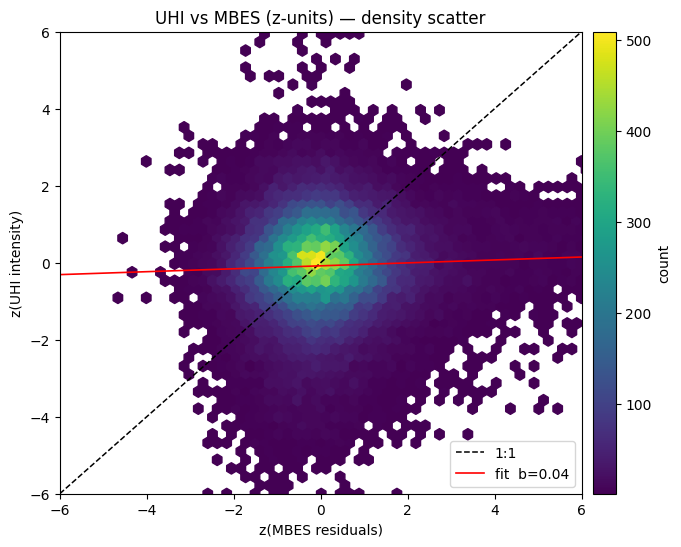

{'r': 0.04082444484618184,
 'a': -0.08037273878569307,
 'b': 0.03810434784829896,
 'n': 56373}

In [ ]:
# choose the UHI files and (optionally) the along-track slice you want
FILE_IDS = ["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"]
TRACK_START = 3039  # or None
TRACK_END = 4029  # or None

data = build_uhi_mbes(FILE_IDS, track_start=TRACK_START, track_end=TRACK_END)

# 2) Set the search ranges and step sizes explicitly (this is where you control speed vs coverage)
params = SearchParams(
    dx_range=(-0.5, 0.5),  # meters
    dy_range=(-0.5, 0.5),  # meters
    theta_range=(-3.0, 3.0),  # degrees
    step_dx=0.5,  # larger step = faster, fewer tries
    step_dy=0.5,
    step_theta=1.0,
    min_overlap=2000,
    show_progress=True,
)

best = run_alignment_search(data, params)
print(
    f"\nFinal verdict: r={best['score']:.3f}  θ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, pairs≈{best['n']}\n"
)

# 3) Make the correlation figure (density scatter) at the best alignment
plot_density_scatter_at(
    data,
    theta_deg=best["theta"],
    dx_m=best["dx"],
    dy_m=best["dy"],
    gridsize=80,
    title="UHI vs MBES (z-units) — density scatter",
)